# GenAI-Augmented Ensemble Methods for Anomaly Detection  
Dataset: NSL-KDD


In [ ]:
!pip install groq -q

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")

Using Colab cache for faster access to the 'nslkdd' dataset.


In [ ]:
# the standard columns for NSL-KDD (41 features + Label + Difficulty)
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "class", "difficulty_level"
]

# Load the datasets
train_df = pd.read_csv(os.path.join(path, "KDDTrain+.txt"), header=None, names=col_names)
test_df = pd.read_csv(os.path.join(path, "KDDTest+.txt"), header=None, names=col_names)


# Dropping 'difficulty_level' column as it is not needed for the classification task
train_df.drop('difficulty_level', axis=1, inplace=True)
test_df.drop('difficulty_level', axis=1, inplace=True)

print("Training Set Shape:", train_df.shape)
print("Test Set Shape:", test_df.shape)

Training Set Shape: (125973, 42)
Test Set Shape: (22544, 42)


In [ ]:
# 1. Inspect the first few rows
print("First 5 rows of Training Data:")
display(train_df.head())

# 2. Check data types (Categorical vs Numerical)
print("\nData Info:")
print(train_df.info())

# 3. Check for missing values
print("\nMissing Values in Training Set:")
print(train_df.isnull().sum().sum())

First 5 rows of Training Data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  


Class Distribution (Normal vs Attack):
class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


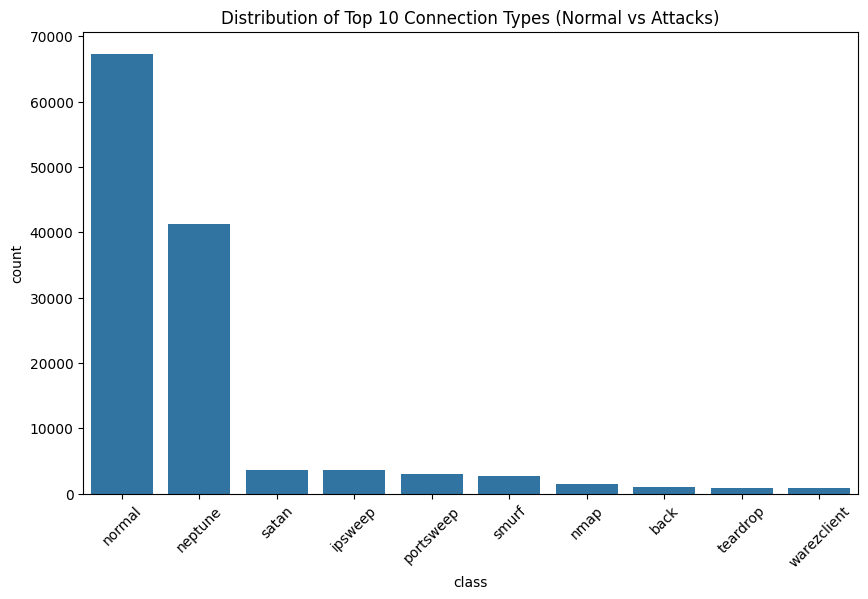


Categorical Features (4): ['protocol_type', 'service', 'flag', 'class']
Numerical Features (38): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [ ]:
# Analyze the target column 'class'
print("\nClass Distribution (Normal vs Attack):")
print(train_df['class'].value_counts())

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=train_df, order=train_df['class'].value_counts().index[:10])
plt.title("Distribution of Top 10 Connection Types (Normal vs Attacks)")
plt.xticks(rotation=45)
plt.show()

# Separate categorical and numerical columns for future reference
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train_df.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nCategorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")

In [ ]:
# Define a cleaning function
def clean_dataset(df):
    initial_shape = df.shape

    # 1. Remove Duplicates
    df = df.drop_duplicates()

    # 2. Drop Missing Values (if any exist)
    df = df.dropna()

    final_shape = df.shape
    dropped_rows = initial_shape[0] - final_shape[0]

    print(f"Cleaning Report: Dropped {dropped_rows} rows.")
    print(f"Final Shape: {final_shape}")

    return df

# Apply cleaning
print("Cleaning Training Data...")
train_df = clean_dataset(train_df)

print("\nCleaning Test Data...")
test_df = clean_dataset(test_df)

Cleaning Training Data...
Cleaning Report: Dropped 0 rows.
Final Shape: (125973, 42)

Cleaning Test Data...
Cleaning Report: Dropped 0 rows.
Final Shape: (22544, 42)


In [ ]:
# Function to check data quality
def check_data_quality(df, name="Dataset"):
    print(f"--- Checking Quality for {name} ---")

    # 1. Missing Values
    missing_count = df.isnull().sum().sum()
    print(f"Total Missing Values: {missing_count}")

    if missing_count > 0:
        print("Columns with missing values:")
        print(df.isnull().sum()[df.isnull().sum() > 0])

    # 2. Duplicate Records
    duplicate_count = df.duplicated().sum()
    print(f"Duplicate Rows Found: {duplicate_count}")
    print("\n")

# Run checks on Train and Test sets
check_data_quality(train_df, "Training Set")
check_data_quality(test_df, "Test Set")

--- Checking Quality for Training Set ---
Total Missing Values: 0
Duplicate Rows Found: 0


--- Checking Quality for Test Set ---
Total Missing Values: 0
Duplicate Rows Found: 0




In [ ]:
# Verify that no nulls or duplicates remain
assert train_df.isnull().sum().sum() == 0, "Error: Training set still has missing values."
assert test_df.isnull().sum().sum() == 0, "Error: Test set still has missing values."
assert train_df.duplicated().sum() == 0, "Error: Training set still has duplicates."

print(" Data Cleaning Complete. Datasets are ready for EDA.")

 Data Cleaning Complete. Datasets are ready for EDA.


In [ ]:
# Check unique labels before transformation
print("Unique labels in Training Set (Top 20):")
print(train_df['class'].unique()[:20])

print("\nNumber of unique labels:", train_df['class'].nunique())

# Grouping by attack types for better visibility
# Common NSL-KDD attack categories:
# DoS: denial of service (e.g., neptune, smurf)
# Probe: surveillance (e.g., satan, ipsweep)
# R2L: unauthorized access from remote (e.g., guess_passwd)
# U2R: unauthorized access to local superuser (e.g., buffer_overflow)

Unique labels in Training Set (Top 20):
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land']

Number of unique labels: 23


In [ ]:
# Function to convert class to binary label
def convert_to_binary(df):
    # Creating a copy to avoid SettingWithCopy warnings
    df = df.copy()

    # Map 'normal' to 0, everything else to 1
    df['label'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

    # Drop the original string 'class' column
    df.drop('class', axis=1, inplace=True)

    return df

# Apply transformation
train_df = convert_to_binary(train_df)
test_df = convert_to_binary(test_df)

print("Transformation Complete.")
print("New columns:", train_df.columns[-5:]) # Show last few columns to verify 'label' exists

Transformation Complete.
New columns: Index(['dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'],
      dtype='object')


Training Set Distribution:
label
0    67343
1    58630
Name: count, dtype: int64
Anomaly Rate: 46.54%

Test Set Distribution:
label
1    12833
0     9711
Name: count, dtype: int64
Anomaly Rate: 56.92%


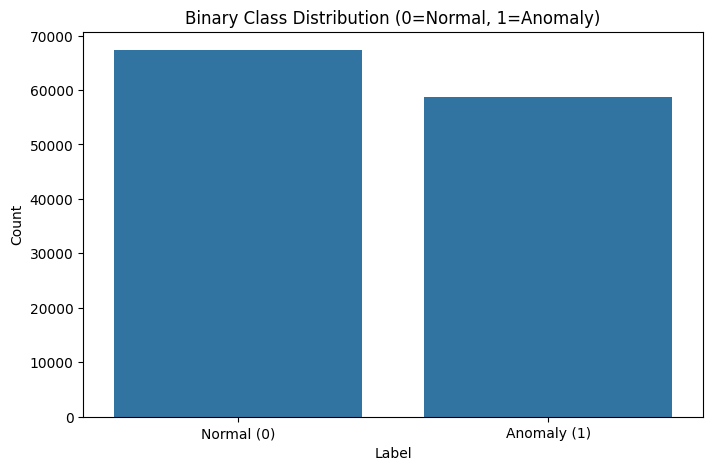

In [ ]:
# Check the new distribution
train_counts = train_df['label'].value_counts()
test_counts = test_df['label'].value_counts()

print("Training Set Distribution:")
print(train_counts)
print(f"Anomaly Rate: {train_counts[1] / len(train_df):.2%}")

print("\nTest Set Distribution:")
print(test_counts)
print(f"Anomaly Rate: {test_counts[1] / len(test_df):.2%}")

# Visualizing the Binary Balance
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train_df)
plt.title('Binary Class Distribution (0=Normal, 1=Anomaly)')
plt.xticks([0, 1], ['Normal (0)', 'Anomaly (1)'])
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 🔹 Step 4: Encoding Categorical Features

**Objective:**
Convert categorical string features (`protocol_type`, `service`, `flag`) into a numerical format suitable for machine learning models.

**Key Actions:**
1.  Identify categorical columns.
2.  Apply **One-Hot Encoding** to create binary columns for each category (e.g., `protocol_type_tcp`, `protocol_type_udp`).
3.  **Align Columns:** Ensure both Training and Test datasets have the exact same columns after encoding. This is critical because the Test set might lack certain rare services present in the Train set (or vice versa).

In [ ]:
# Select categorical columns automatically
# In NSL-KDD these are usually: 'protocol_type', 'service', 'flag'
categorical_cols = train_df.select_dtypes(include=['object']).columns
print(f"Categorical Columns to Encode: {list(categorical_cols)}")

# Apply One-Hot Encoding
# We concat train and test temporarily to ensure consistent dummy variables
train_df['is_train'] = 1
test_df['is_train'] = 0

# Combine
combined_df = pd.concat([train_df, test_df], axis=0)

# Encode
combined_df_encoded = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)

# Split back into Train and Test
train_df_encoded = combined_df_encoded[combined_df_encoded['is_train'] == 1].drop('is_train', axis=1)
test_df_encoded = combined_df_encoded[combined_df_encoded['is_train'] == 0].drop('is_train', axis=1)

print("Encoding Complete.")
print(f"New Training Shape: {train_df_encoded.shape}")
print(f"New Test Shape: {test_df_encoded.shape}")

Categorical Columns to Encode: ['protocol_type', 'service', 'flag']
Encoding Complete.
New Training Shape: (125973, 120)
New Test Shape: (22544, 120)


In [ ]:
# Check the first few rows of the new encoded columns
# We look for columns starting with 'protocol_type' or 'service'
sample_cols = [col for col in train_df_encoded.columns if 'protocol_type' in col or 'service' in col]

print("Sample Encoded Columns:")
display(train_df_encoded[sample_cols[:5]].head())

# Verify all data is now numeric
assert train_df_encoded.select_dtypes(include=['object']).shape[1] == 0, "Error: Categorical columns remain!"
print(" Verification Successful: All features are now numeric.")

Sample Encoded Columns:


,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol
0,True,False,False,False,False
1,False,True,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False


 Verification Successful: All features are now numeric.


## 🔹 Step 5: Feature Scaling / Normalization

**Objective:**
Scale numerical features to a uniform range (0 to 1). This prevents features with large magnitudes (like `src_bytes`) from dominating the model's loss function and ensures compatibility with the GenAI (VAE) module.

**Key Actions:**
1.  Separate the Target (`label`) from the Features (`X`).
2.  Identify the continuous numerical columns (e.g., `duration`, `src_bytes`) vs. binary encoded columns.
3.  Apply **MinMaxScaler** to the continuous features.
    * **Crucial:** Fit the scaler *only* on the Training set, then transform both Train and Test sets. This prevents "data leakage."

In [ ]:
# Separate features (X) and target (y)
X_train = train_df_encoded.drop('label', axis=1)
y_train = train_df_encoded['label']

X_test = test_df_encoded.drop('label', axis=1)
y_test = test_df_encoded['label']

print(f"Features Shape: {X_train.shape}")
print(f"Target Shape: {y_train.shape}")

Features Shape: (125973, 119)
Target Shape: (125973,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Identify columns to scale
# We use the list of numerical columns found in Step 1, but exclude 'label' and 'difficulty_level'
cols_to_scale = [col for col in numerical_cols if col in X_train.columns]

print(f"Scaling {len(cols_to_scale)} continuous features...")

# 2. Initialize the Scaler
scaler = MinMaxScaler()

# 3. Fit on TRAIN data only, then Transform both Train and Test
# We allow the scaler to modify the dataframe in place for these specific columns
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Normalization Complete.")

Scaling 38 continuous features...
Normalization Complete.


Statistics for 'src_bytes' after scaling:
count    1.259730e+05
mean     3.302024e-05
std      4.253974e-03
min      0.000000e+00
25%      0.000000e+00
50%      3.188489e-08
75%      2.000052e-07
max      1.000000e+00
Name: src_bytes, dtype: float64

Min Value: 0.0
Max Value: 1.0


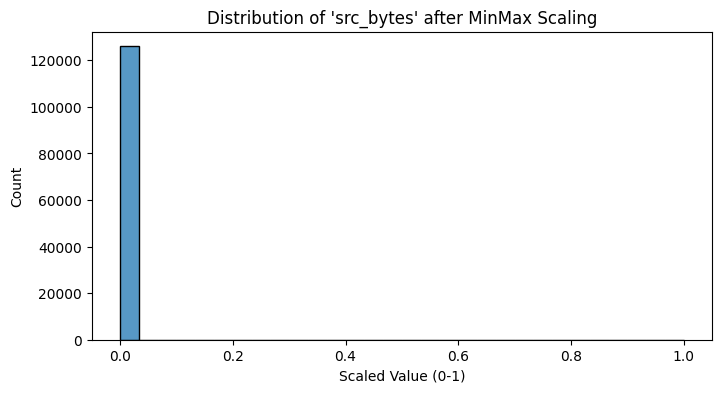

In [ ]:
# Check statistics for a specific column, e.g., 'src_bytes' or 'duration'
# Choose a column that definitely exists in the numerical list
check_col = 'src_bytes' if 'src_bytes' in X_train.columns else cols_to_scale[0]

print(f"Statistics for '{check_col}' after scaling:")
print(X_train[check_col].describe())

# Verify Range
print(f"\nMin Value: {X_train[check_col].min()}")
print(f"Max Value: {X_train[check_col].max()}")

# Visual check
plt.figure(figsize=(8, 4))
sns.histplot(X_train[check_col], bins=30)
plt.title(f"Distribution of '{check_col}' after MinMax Scaling")
plt.xlabel("Scaled Value (0-1)")
plt.show()

## 🔹 Step 6: Train-Test-Validation Split

**Objective:**
Divide the entire dataset into three distinct subsets to ensure robust model training and evaluation:
1.  **Training Set (70%):** Used to fit the Single Learners and Ensemble models.
2.  **Validation Set (15%):** Used for hyperparameter tuning (e.g., threshold selection for Isolation Forest) and early stopping.
3.  **Test Set (15%):** Used for the final unbiased performance evaluation.

**Key Actions:**
1.  **Concatenate** the original `train_df` and `test_df` features and labels into a single pool.
2.  **Stratified Split 1:** Separate 70% of the data for **Training**.
3.  **Stratified Split 2:** Split the remaining 30% equally (50/50) into **Validation** (15%) and **Testing** (15%).

In [ ]:
# 1. Concatenate features and labels
# We use the scaled features from Step 5
X_total = pd.concat([X_train, X_test], axis=0)
y_total = pd.concat([y_train, y_test], axis=0)

print(f"Total Samples: {X_total.shape[0]}")
print(f"Total Features: {X_total.shape[1]}")

Total Samples: 148517
Total Features: 119


In [ ]:
from sklearn.model_selection import train_test_split

# First Split: Separate Training (70%) from the Rest (30%)
X_train_final, X_temp, y_train_final, y_temp = train_test_split(
    X_total, y_total,
    test_size=0.30,
    random_state=42,
    stratify=y_total
)

# Second Split: Divide the Rest (30%) into Validation (15%) and Testing (15%)
# We split the 30% chunk in half (0.5), resulting in 15% of the total each.
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Split Completed.")

Split Completed.


In [ ]:
# Calculate counts
total_count = len(X_total)
train_count = len(X_train_final)
val_count = len(X_val)
test_count = len(X_test_final)

# Print Distribution
print(f"Training Set:   {train_count} samples ({train_count/total_count:.2%})")
print(f"Validation Set: {val_count} samples ({val_count/total_count:.2%})")
print(f"Test Set:       {test_count} samples ({test_count/total_count:.2%})")

# Verify Anomaly Stratification
print("\nAnomaly Rate in Splits:")
print(f"Train: {y_train_final.mean():.4f}")
print(f"Val:   {y_val.mean():.4f}")
print(f"Test:  {y_test_final.mean():.4f}")
# These values should be nearly identical

Training Set:   103961 samples (70.00%)
Validation Set: 22278 samples (15.00%)
Test Set:       22278 samples (15.00%)

Anomaly Rate in Splits:
Train: 0.4812
Val:   0.4812
Test:  0.4811


## 🔹 Step 7: Exploratory Data Analysis (EDA)

**Objective:**
Visually and statistically analyze the training data to understand:
1.  **Class Imbalance:** Confirm the proportion of anomalies vs. normal traffic.
2.  **Correlation:** Identify redundant features or features strongly correlated with the label.
3.  **Distributions & Outliers:** Visualize feature spread and detect potential outliers using boxplots.

**Key Actions:**
1.  Recombine features and labels into a temporary DataFrame for plotting.
2.  Generate a **Correlation Heatmap**.
3.  Plot **Histograms** and **Boxplots** for key features.

In [ ]:
# Create a temporary DataFrame for EDA using the Training split
eda_df = X_train_final.copy()
eda_df['label'] = y_train_final

print("EDA DataFrame Shape:", eda_df.shape)
print("Preview:")
display(eda_df.head())

EDA DataFrame Shape: (103961, 120)
Preview:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,label
939,0.0,1.884107e-07,2.160409e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,True,False,0
35399,0.0,2.115997e-07,3.842932e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,True,False,0
86613,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,1
81333,0.0,2.130491e-07,9.519539e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,True,False,0
74256,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,1


Class Distribution:
 label
0    53937
1    50024
Name: count, dtype: int64


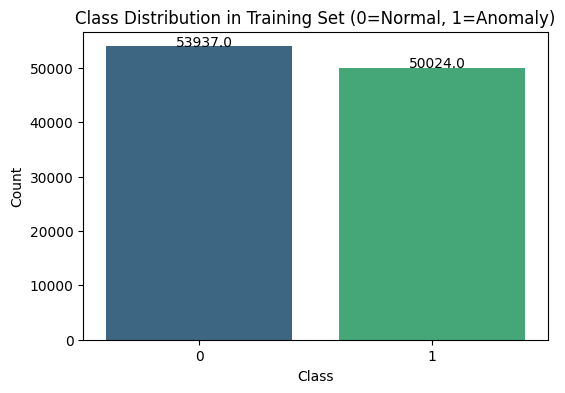

In [ ]:
# 1. Class Counts
class_counts = eda_df['label'].value_counts()
print("Class Distribution:\n", class_counts)

# 2. Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=eda_df, palette='viridis')

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))

plt.title("Class Distribution in Training Set (0=Normal, 1=Anomaly)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

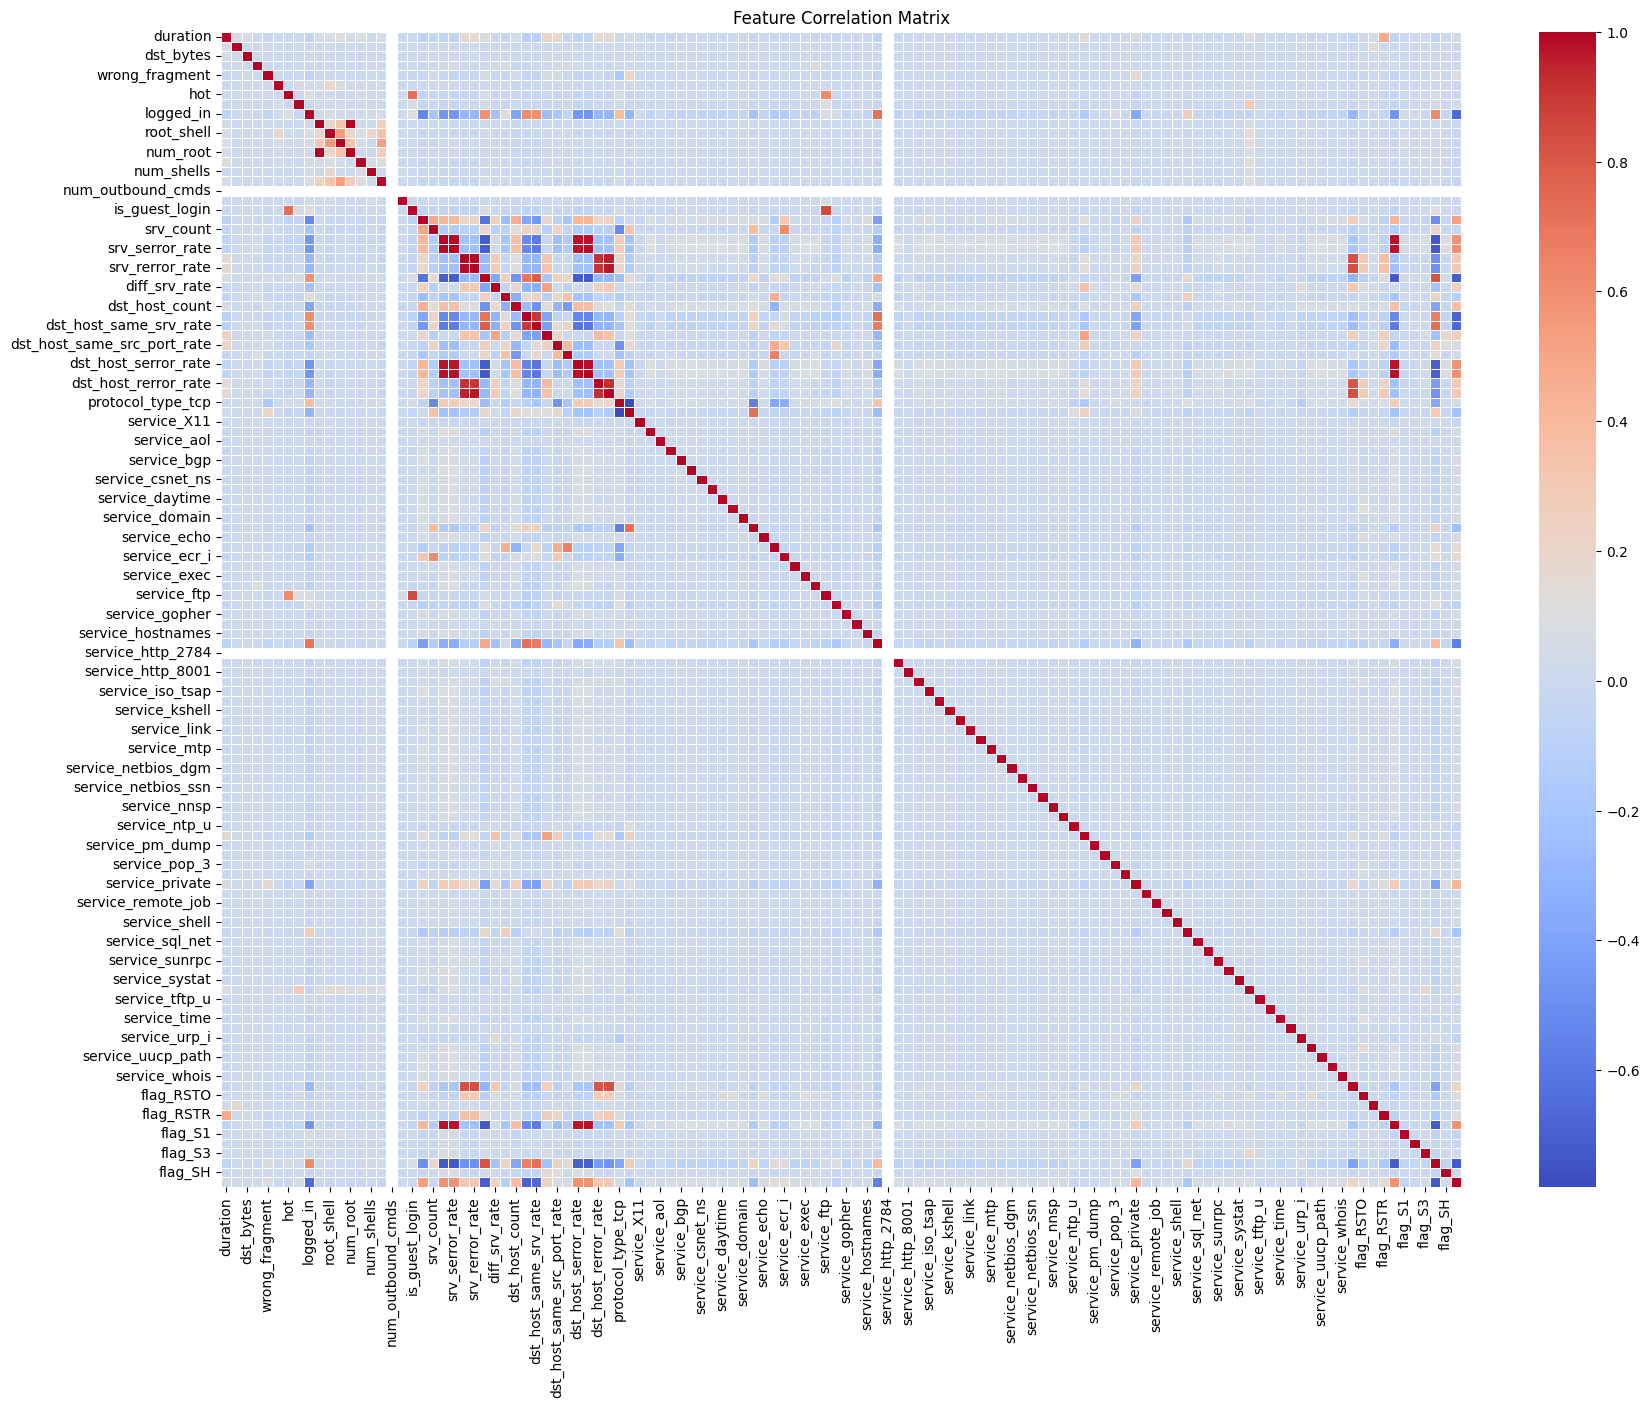


Top 10 Features most correlated with Anomaly Label:
flag_SF                     0.727428
same_srv_rate               0.708791
dst_host_srv_count          0.692281
dst_host_same_srv_rate      0.667619
logged_in                   0.663559
dst_host_srv_serror_rate    0.593961
dst_host_serror_rate        0.589793
serror_rate                 0.588330
srv_serror_rate             0.586609
flag_S0                     0.585829
Name: label, dtype: float64


In [ ]:
# Calculate correlation matrix
corr_matrix = eda_df.corr()

# Plot Heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".1f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Top 10 features most correlated with the 'label'
# (Absolute correlation to capture both positive and negative relationships)
top_corr_features = abs(corr_matrix["label"]).sort_values(ascending=False).head(11) # Top 10 + Label
print("\nTop 10 Features most correlated with Anomaly Label:")
print(top_corr_features.drop('label'))

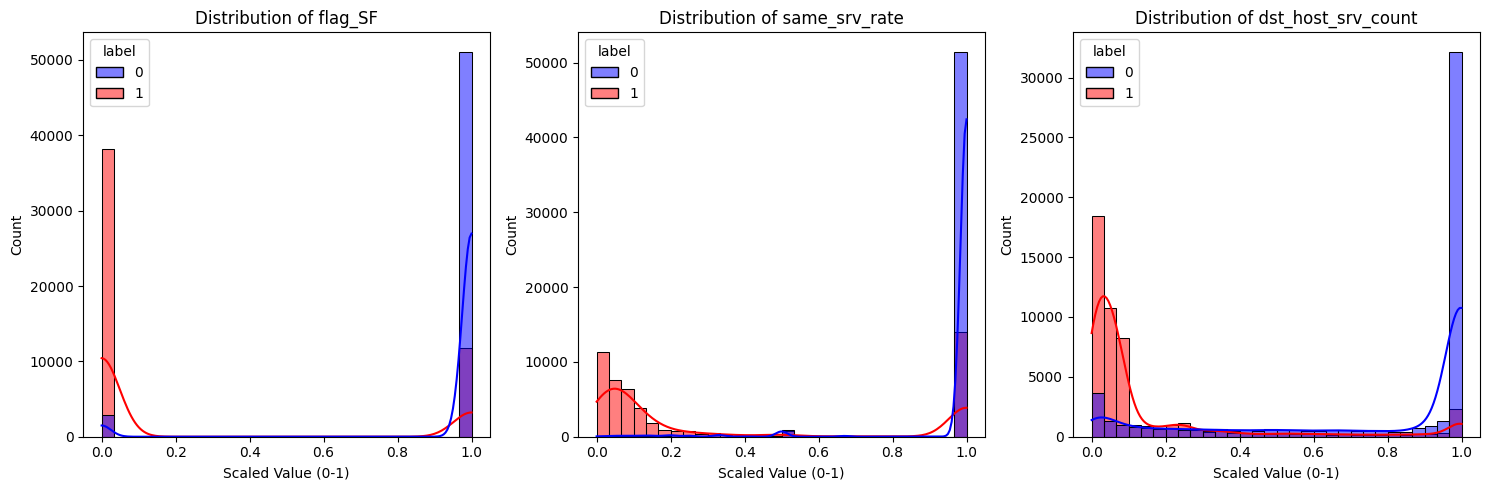

In [ ]:
# Select top 3 correlated features (excluding label)
top_features = top_corr_features.drop('label').index[:3]

plt.figure(figsize=(15, 5))

for i, col in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    # Plot distribution for Normal vs Anomaly
    sns.histplot(data=eda_df, x=col, hue='label', kde=True, bins=30, palette={0: 'blue', 1: 'red'})
    plt.title(f"Distribution of {col}")
    plt.xlabel("Scaled Value (0-1)")

plt.tight_layout()
plt.show()

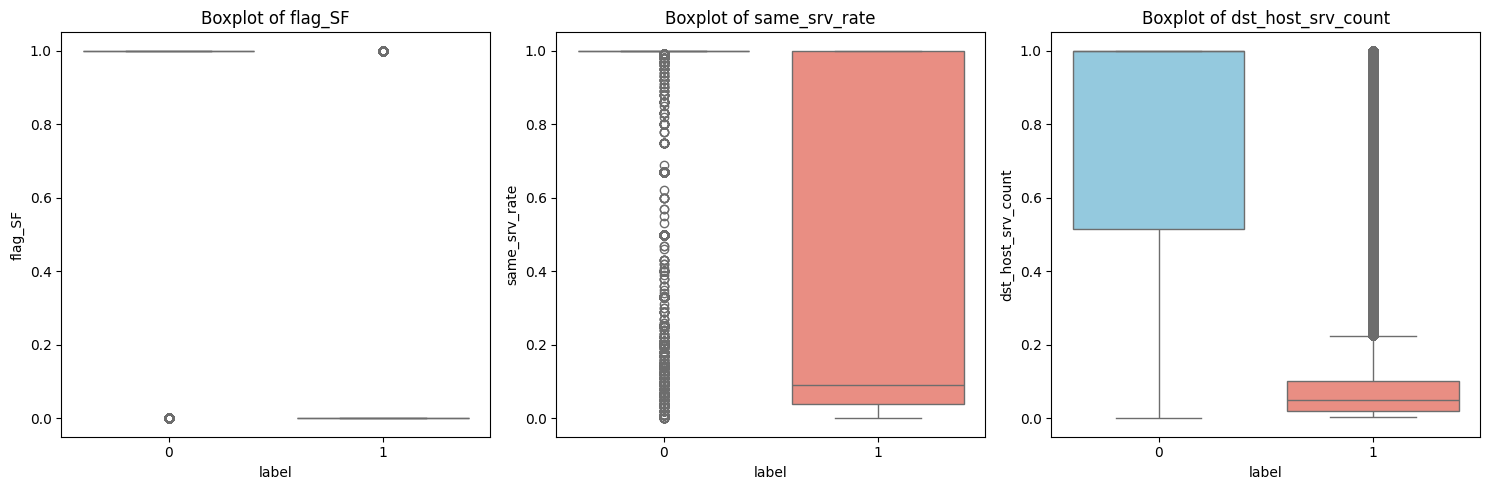

In [ ]:
# Plot Boxplots for the same top 3 features
plt.figure(figsize=(15, 5))

for i, col in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    # CHANGE: Use string keys '0' and '1' instead of integers
    sns.boxplot(
        x='label',
        y=col,
        data=eda_df,
        palette={'0': 'skyblue', '1': 'salmon'}
    )
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

## 🔹 Step 8: Baseline Model Training (Single Learners)

**Objective:**
Train and evaluate individual baseline models to establish a performance benchmark. We will use:
1.  **Isolation Forest:** An ensemble of trees that isolates anomalies (short paths).
2.  **One-Class SVM (OCSVM):** Maps data to a high-dimensional space and finds a hyperplane separating "normal" data from the origin.
3.  **Autoencoder:** A deep learning model that learns to compress and reconstruct data. High reconstruction error indicates an anomaly.

**Key Actions:**
1.  Train each model using the **Training Set**.
    * *Note:* For the Autoencoder and OCSVM, it is often best practice to train primarily on "Normal" data so the model learns normality, though Isolation Forest handles mixed data well.
2.  Predict on the **Test Set**.
3.  Calculate metrics: **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    print(f"--- Performance: {model_name} ---")

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    if y_pred_proba is not None:
        auc = roc_auc_score(y_true, y_pred_proba)
        print(f"AUC-ROC:   {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n" + "="*30 + "\n")

    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

# Store results for final comparison
baseline_results = []

In [ ]:
from sklearn.ensemble import IsolationForest

# 1. Initialize
# contamination='auto' lets the model estimate the % of outliers,
# or we can set it to the approximate anomaly rate calculated in Step 3.
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)

# 2. Train (Fit on Training Data)
print("Training Isolation Forest...")
iso_forest.fit(X_train_final)

# 3. Predict
# Isolation Forest returns -1 for outliers and 1 for inliers.
# We need to map this to our format: 0 for Normal, 1 for Anomaly.
y_pred_iso_raw = iso_forest.predict(X_test_final)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso_raw]

# 4. Evaluate
res_iso = evaluate_model("Isolation Forest", y_test_final, y_pred_iso)
baseline_results.append(res_iso)

Training Isolation Forest...
--- Performance: Isolation Forest ---
Accuracy:  0.5189
Precision: 0.5000
Recall:    0.0002
F1 Score:  0.0004

Confusion Matrix:
[[11557     2]
 [10717     2]]




In [ ]:
from sklearn.svm import OneClassSVM

# 1. Prepare Data
# OCSVM works best when trained on "Normal" data only.
# We filter the training set for Normal instances (label == 0).
X_train_normal = X_train_final[y_train_final == 0]

# 2. Initialize
# nu: An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)

# 3. Train
# Warning: This might take a few minutes.
print("Training One-Class SVM (this may take time)...")
# For speed in this demo, we can train on a subset (e.g., first 20k rows)
oc_svm.fit(X_train_normal[:20000])

# 4. Predict
y_pred_svm_raw = oc_svm.predict(X_test_final)
y_pred_svm = [1 if x == -1 else 0 for x in y_pred_svm_raw]

# 5. Evaluate
res_svm = evaluate_model("One-Class SVM", y_test_final, y_pred_svm)
baseline_results.append(res_svm)

Training One-Class SVM (this may take time)...
--- Performance: One-Class SVM ---
Accuracy:  0.9210
Precision: 0.9429
Recall:    0.8895
F1 Score:  0.9155

Confusion Matrix:
[[10982   577]
 [ 1184  9535]]




In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses

# 1. Prepare Data (Train on Normal only)
# We already defined X_train_normal in the OCSVM block.

# 2. Define Architecture
input_dim = X_train_final.shape[1]

autoencoder = models.Sequential([
    # Encoder
    layers.Dense(32, activation='relu', input_shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'), # Bottleneck

    # Decoder
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid') # Output scaled 0-1 (matches MinMax)
])

autoencoder.compile(optimizer='adam', loss='mae')

# 3. Train
print("Training Autoencoder...")
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=10,
    batch_size=64,
    validation_data=(X_val[y_val==0], X_val[y_val==0]),
    shuffle=True,
    verbose=1
)

# 4. Predict & Thresholding
# Get reconstruction error on Test Set
reconstructions = autoencoder.predict(X_test_final)
mae = np.mean(np.abs(reconstructions - X_test_final), axis=1)

# Determine Threshold (Using the 95th percentile of Validation Errors as a simple heuristic)
# In a real study, you might tune this on the Validation set to maximize F1.
val_reconstructions = autoencoder.predict(X_val)
val_mae = np.mean(np.abs(val_reconstructions - X_val), axis=1)
threshold = np.percentile(val_mae, 95)

print(f"Autoencoder Threshold: {threshold:.4f}")

# Map to binary (Error > Threshold = 1 (Anomaly))
y_pred_ae = [1 if e > threshold else 0 for e in mae]

# 5. Evaluate
res_ae = evaluate_model("Autoencoder", y_test_final, y_pred_ae)
baseline_results.append(res_ae)

Training Autoencoder...
Epoch 1/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1173 - val_loss: 0.0218
Epoch 2/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0211 - val_loss: 0.0176
Epoch 3/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0174 - val_loss: 0.0159
Epoch 4/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0155 - val_loss: 0.0152
Epoch 5/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0151 - val_loss: 0.0145
Epoch 6/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0144 - val_loss: 0.0144
Epoch 7/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0142 - val_loss: 0.0143
Epoch 8/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0141 - val_loss: 0.0141
Epoch 9/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0139 - val_loss: 0.0137
Epoch 10/10
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0136 - val_loss: 0.0135
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Autoencoder Threshold: 0.0810
--

In [ ]:
# Display comparison table
baseline_df = pd.DataFrame(baseline_results)
print("Baseline Models Comparison:")
display(baseline_df)

Baseline Models Comparison:


,Model,Accuracy,Precision,Recall,F1
0,Isolation Forest,0.518853,0.500000,0.000187,0.000373
1,One-Class SVM,0.920953,0.942939,0.889542,0.915463
2,Autoencoder,0.571191,0.997440,0.109059,0.196619


## 🔹 Step 9: Traditional Ensemble Models

**Objective:**
Combine the predictions from the baseline single learners (Isolation Forest, One-Class SVM, Autoencoder) to create a more robust detection system.

**Key Actions:**
1.  **Generate Predictions:** Obtain prediction vectors (0 or 1) from all three base models on the Test Set.
2.  **Hard Voting (Majority Rule):** An instance is an anomaly if >50% of models say so.
3.  **Weighted Voting:** Assign higher importance to better-performing models (e.g., Autoencoder).
4.  **Stacking (Optional/Advanced):** Use a meta-learner (Logistic Regression) to learn how to best combine the base model outputs.

In [ ]:
# 1. Isolation Forest Predictions
# y_pred_iso

# 2. One-Class SVM Predictions
# y_pred_svm

# 3. Autoencoder Predictions
# y_pred_ae

ensemble_df = pd.DataFrame({
    'ISO': y_pred_iso,
    'SVM': y_pred_svm,
    'AE': y_pred_ae
})

print("Prediction Correlation Matrix:")
# Check how much the models agree with each other
print(ensemble_df.corr())

Prediction Correlation Matrix:
          ISO       SVM        AE
ISO  1.000000  0.014699  0.011849
SVM  0.014699  1.000000  0.258474
AE   0.011849  0.258474  1.000000


In [ ]:
# Majority Voting: Sum of rows >= 2 means Anomaly (1)
ensemble_df['Sum'] = ensemble_df.sum(axis=1)
y_pred_majority = ensemble_df['Sum'].apply(lambda x: 1 if x >= 2 else 0)

# Evaluate
res_majority = evaluate_model("Ensemble (Majority Voting)", y_test_final, y_pred_majority)
baseline_results.append(res_majority)

--- Performance: Ensemble (Majority Voting) ---
Accuracy:  0.5711
Precision: 0.9957
Recall:    0.1092
F1 Score:  0.1967

Confusion Matrix:
[[11554     5]
 [ 9549  1170]]




In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# --- Derive weights from VALIDATION F1 (proxy for validation accuracy on imbalanced data) ---
val_pred_iso = [1 if x == -1 else 0 for x in iso_forest.predict(X_val)]
val_pred_svm = [1 if x == -1 else 0 for x in oc_svm.predict(X_val)]

val_reconstructions = autoencoder.predict(X_val)
val_mae = np.mean(np.abs(val_reconstructions - X_val), axis=1)
val_pred_ae = [1 if e > threshold else 0 for e in val_mae]

f1_iso = f1_score(y_val, val_pred_iso, zero_division=0)
f1_svm = f1_score(y_val, val_pred_svm, zero_division=0)
f1_ae  = f1_score(y_val, val_pred_ae,  zero_division=0)

raw = np.array([f1_ae, f1_iso, f1_svm], dtype=float) + 1e-9
raw = raw / raw.sum()
w_ae, w_iso, w_svm = raw.tolist()

print(f"Validation-derived weights -> AE:{w_ae:.3f}, ISO:{w_iso:.3f}, SVM:{w_svm:.3f}")

# --- Weighted voting (same logic as before) ---
weighted_score = (
    ensemble_df['AE'] * w_ae +
    ensemble_df['ISO'] * w_iso +
    ensemble_df['SVM'] * w_svm
)

y_pred_weighted = weighted_score.apply(lambda x: 1 if x >= 0.5 else 0)


# Threshold: If weighted sum >= 0.5, classify as 1
y_pred_weighted = weighted_score.apply(lambda x: 1 if x >= 0.5 else 0)

# Evaluate
res_weighted = evaluate_model("Ensemble (Weighted Voting)", y_test_final, y_pred_weighted)
baseline_results.append(res_weighted)

697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation-derived weights -> AE:0.172, ISO:0.001, SVM:0.827
--- Performance: Ensemble (Weighted Voting) ---
Accuracy:  0.9210
Precision: 0.9429
Recall:    0.8895
F1 Score:  0.9155

Confusion Matrix:
[[10982   577]
 [ 1184  9535]]




In [ ]:
from sklearn.metrics import f1_score

# Derive weights from VALIDATION F1 (proxy for "validation accuracy" in imbalanced setting)
val_pred_iso = [1 if x == -1 else 0 for x in iso_forest.predict(X_val)]
val_pred_svm = [1 if x == -1 else 0 for x in oc_svm.predict(X_val)]

val_reconstructions = autoencoder.predict(X_val)
val_mae = np.mean(np.abs(val_reconstructions - X_val), axis=1)
val_pred_ae = [1 if e > threshold else 0 for e in val_mae]

f1_iso = f1_score(y_val, val_pred_iso, zero_division=0)
f1_svm = f1_score(y_val, val_pred_svm, zero_division=0)
f1_ae  = f1_score(y_val, val_pred_ae,  zero_division=0)

raw = np.array([f1_ae, f1_iso, f1_svm], dtype=float) + 1e-9
raw = raw / raw.sum()

w_ae, w_iso, w_svm = raw.tolist()
print(f"Validation-derived weights -> AE:{w_ae:.3f}, ISO:{w_iso:.3f}, SVM:{w_svm:.3f}")


697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation-derived weights -> AE:0.172, ISO:0.001, SVM:0.827


Final Performance Comparison:


,Model,Accuracy,Precision,Recall,F1
1,One-Class SVM,0.920953,0.942939,0.889542,0.915463
4,Ensemble (Weighted Voting),0.920953,0.942939,0.889542,0.915463
3,Ensemble (Majority Voting),0.571146,0.995745,0.109152,0.196738
2,Autoencoder,0.571191,0.997440,0.109059,0.196619
0,Isolation Forest,0.518853,0.500000,0.000187,0.000373


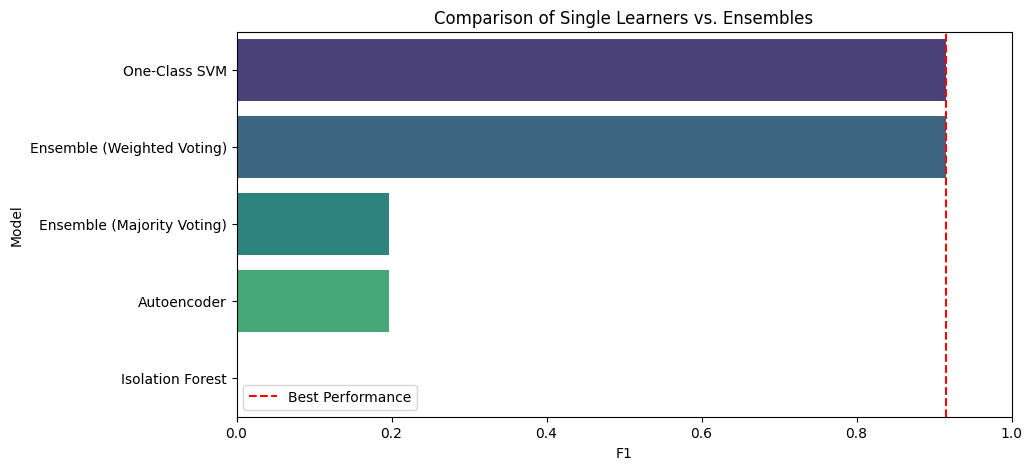

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(baseline_results)

# Sort by F1 Score
results_df = results_df.sort_values(by="F1", ascending=False)

print("Final Performance Comparison:")
display(results_df)

# Plot F1 Scores
plt.figure(figsize=(10, 5))
sns.barplot(x="F1", y="Model", data=results_df, palette="viridis")
plt.title("Comparison of Single Learners vs. Ensembles")
plt.xlim(0, 1.0)
plt.axvline(x=results_df['F1'].max(), color='r', linestyle='--', label='Best Performance')
plt.legend()
plt.show()

## 🔹 Step 10: Generative AI Augmentation (Synthetic Data)

**Objective:**
Use Generative AI (specifically a Variational Autoencoder or VAE) to generate high-fidelity synthetic anomaly samples. This addresses the class imbalance problem by enriching the minority class (attacks) with diverse, realistic examples.

**Key Actions:**
1.  **Isolate Minority Class:** Extract existing anomaly samples from the training set.
2.  **Train GenAI Model (VAE):** Train a VAE specifically on these anomalies to learn their latent distribution.
3.  **Generate Synthetic Anomalies:** Sample from the learned latent space to create new, unique anomaly records.
4.  **Augment Dataset:** Combine the original training data with the new synthetic anomalies to create `X_train_augmented`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# 1. Isolate Anomalies
X_train_anomalies = X_train_final[y_train_final == 1]

# 2. Define Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 3. Build VAE with HIGHER Latent Dimension
latent_dim = 8
input_dim = X_train_anomalies.shape[1]

# Encoder
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# Compile
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    def train_step(self, data):
        if isinstance(data, tuple): data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(data, reconstruction)) * input_dim
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

print("Training VAE (High-Dim) on Anomaly Data...")
history = vae.fit(X_train_anomalies, epochs=30, batch_size=64, verbose=1)

# 4. Generate Synthetic Data
n_to_generate = 2000
random_latent_vectors = tf.random.normal(shape=(n_to_generate, latent_dim))
synthetic_anomalies = decoder.predict(random_latent_vectors)
synthetic_df = pd.DataFrame(synthetic_anomalies, columns=X_train_final.columns)
synthetic_df['label'] = 1

# 5. Augment Training Set
train_df_original = X_train_final.copy()
train_df_original['label'] = y_train_final
train_df_augmented = pd.concat([train_df_original, synthetic_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_aug = train_df_augmented.drop('label', axis=1)
y_train_aug = train_df_augmented['label']
print(f"VAE Augmentation Complete. New Training Size: {len(X_train_aug)}")

Training VAE (High-Dim) on Anomaly Data...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 26.6910
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.3209
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.3773
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.0515
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.8968
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.7307
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.6165
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4607
Epoch 9/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.3624
Epoch 10/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.2948
Epoch 11/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.2214
Epoch 12/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.2159
Epoch 13/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.1708
Epoch 14/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.1526
Epoch 15/30


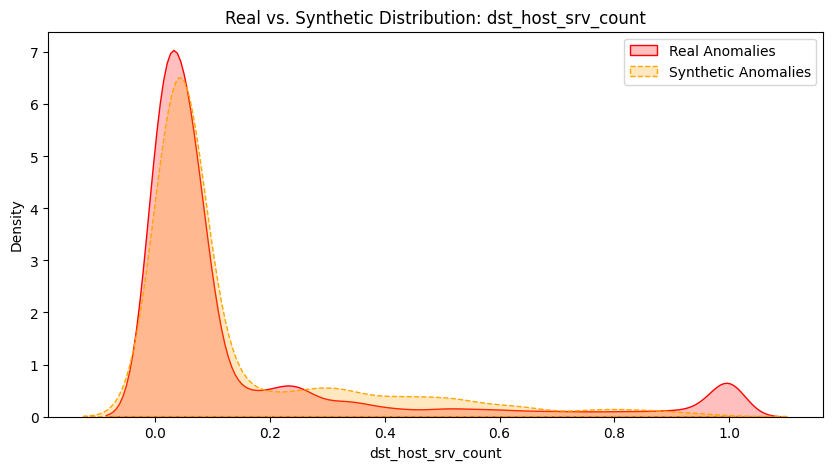

In [ ]:
# Visualize Real vs Synthetic distribution for a key feature (e.g., src_bytes)
feature_to_plot = 'dst_host_srv_count' # Example feature

plt.figure(figsize=(10, 5))
sns.kdeplot(X_train_anomalies[feature_to_plot], label='Real Anomalies', fill=True, color='red')
sns.kdeplot(synthetic_df[feature_to_plot], label='Synthetic Anomalies', fill=True, color='orange', linestyle='--')
plt.title(f"Real vs. Synthetic Distribution: {feature_to_plot}")
plt.legend()
plt.show()

In [ ]:
# TARGETED GAN AUGMENTATION (Hard Negatives)
import tensorflow as tf
from tensorflow.keras import layers

# 1. Identify "Hard" Anomalies (Those ISO Forest thought were Normal)
anomaly_scores = iso_forest.decision_function(X_train_anomalies)
# Lower scores = more anomalous. Higher scores = more normal-looking (harder to detect).
hard_threshold = np.percentile(anomaly_scores, 50)
hard_indices = np.where(anomaly_scores >= hard_threshold)[0]
X_hard_anomalies = X_train_anomalies.iloc[hard_indices]

print(f"Training GAN on {len(X_hard_anomalies)} 'Hard' Anomalies...")

# 2. Fast GAN Setup (Targeted)
BATCH_SIZE = 128
dataset_gan = tf.data.Dataset.from_tensor_slices(X_hard_anomalies.astype('float32').values).shuffle(1000).batch(BATCH_SIZE)
input_dim = X_train_anomalies.shape[1]
noise_dim = 32

generator = tf.keras.Sequential([
    layers.Dense(32, activation='relu', input_dim=noise_dim),
    layers.Dense(input_dim, activation='sigmoid')
])

discriminator = tf.keras.Sequential([
    layers.Dense(32, activation='relu', input_dim=input_dim),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')
discriminator.trainable = False

gan_input = layers.Input(shape=(noise_dim,))
gan = tf.keras.Model(gan_input, discriminator(generator(gan_input)))
gan.compile(optimizer='adam', loss='binary_crossentropy')

# 3. Fast Training (50 Epochs)
for epoch in range(50):
    for real_data in dataset_gan:
        batch_curr = tf.shape(real_data)[0]
        # Train Discriminator
        noise = tf.random.normal(shape=(batch_curr, noise_dim))
        fake_data = generator(noise)
        discriminator.train_on_batch(real_data, tf.ones((batch_curr, 1)))
        discriminator.train_on_batch(fake_data, tf.zeros((batch_curr, 1)))
        # Train Generator
        gan.train_on_batch(tf.random.normal(shape=(batch_curr, noise_dim)), tf.ones((batch_curr, 1)))

# 4. Generate & Augment
synthetic_gan = generator.predict(tf.random.normal(shape=(500, noise_dim)))
synthetic_gan_df = pd.DataFrame(synthetic_gan, columns=X_train_final.columns)
synthetic_gan_df['label'] = 1

# Add to the existing Augmented Set
X_train_aug = pd.concat([X_train_aug, synthetic_gan_df.drop('label', axis=1)], axis=0)
y_train_aug = pd.concat([y_train_aug, synthetic_gan_df['label']], axis=0)

print(f"Targeted GAN Augmentation Complete. Final Training Size: {len(X_train_aug)}")

Training GAN on 25014 'Hard' Anomalies...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Targeted GAN Augmentation Complete. Final Training Size: 106461


In [ ]:
print(f"Retraining models on Augmented Data (Size: {len(X_train_aug)})...")

# 1. Retrain Isolation Forest
iso_forest_aug = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
iso_forest_aug.fit(X_train_aug)
print("Isolation Forest Retrained.")

# 2. Retrain One-Class SVM (On Normal data only - Augmentation doesn't help OCSVM much, but we keep consistency)
print("One-Class SVM: Keeping original (trained on normal only).")

# 3. Retrain Autoencoder
# Autoencoders learn "normality". Training them on synthetic ANOMALIES is actually bad.
# So we DO NOT retrain the Autoencoder on the augmented anomaly dataset.
print("Autoencoder: Keeping original (trained on normal only).")

# 4.  Train a Supervised Classifier
# Since we now have a rich labeled dataset (X_train_aug), we can add a Random Forest!
from sklearn.ensemble import RandomForestClassifier
rf_aug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aug.fit(X_train_aug, y_train_aug)
print("New Component: Supervised Random Forest Trained on GenAI Data.")

Retraining models on Augmented Data (Size: 106461)...
Isolation Forest Retrained.
One-Class SVM: Keeping original (trained on normal only).
Autoencoder: Keeping original (trained on normal only).
New Component: Supervised Random Forest Trained on GenAI Data.


## 🔹 Step 11: Feature Representation using GenAI (Enrichment)

**Objective:**
Extract the "hidden knowledge" captured by the GenAI model. We will use the **Encoder** part of the VAE to transform the high-dimensional input data into a compressed **Latent Representation (Embedding)**.

**Key Actions:**
1.  **Extract Latent Features:** Pass the Training, Validation, and Test sets through the trained VAE Encoder to get the latent vectors ($z_{mean}$).
2.  **Feature Fusion:** Concatenate these new latent features with the original input features.
3.  **Create Enriched Datasets:** Produce `X_train_enriched`, `X_val_enriched`, and `X_test_enriched`.

**Hypothesis:**
These latent features represent the "structural essence" of the data. [cite_start]Adding them should help linear models (like SVM) separate anomalies better.

Extracting latent features using VAE Encoder...
3249/3249 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Enriched Feature Count: 127 (+8 latent)


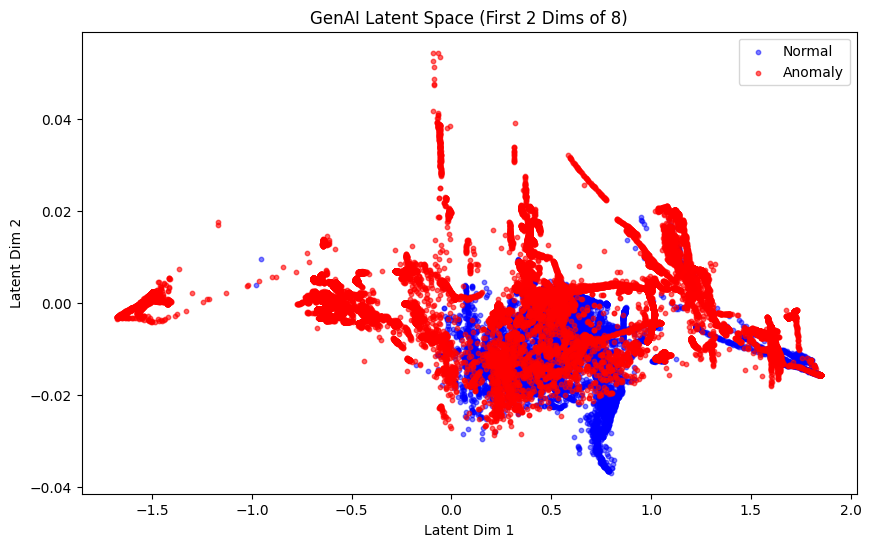

In [ ]:
# 1. Extract Latent Features (Dimension = 8)
print("Extracting latent features using VAE Encoder...")
z_train = encoder.predict(X_train_final)[0]
z_val = encoder.predict(X_val)[0]
z_test = encoder.predict(X_test_final)[0]

latent_cols = [f"latent_{i}" for i in range(z_train.shape[1])]
z_train_df = pd.DataFrame(z_train, columns=latent_cols, index=X_train_final.index)
z_val_df = pd.DataFrame(z_val, columns=latent_cols, index=X_val.index)
z_test_df = pd.DataFrame(z_test, columns=latent_cols, index=X_test_final.index)

# 2. Concatenate
X_train_enriched = pd.concat([X_train_final, z_train_df], axis=1)
X_val_enriched = pd.concat([X_val, z_val_df], axis=1)
X_test_enriched = pd.concat([X_test_final, z_test_df], axis=1)

print(f"Enriched Feature Count: {X_train_enriched.shape[1]} (+{len(latent_cols)} latent)")

# 3. Visualize First 2 Latent Dimensions
plt.figure(figsize=(10, 6))
mask_normal = (y_train_final == 0).values
mask_anomaly = (y_train_final == 1).values

plt.scatter(z_train_df.iloc[mask_normal, 0], z_train_df.iloc[mask_normal, 1], c='blue', alpha=0.5, label='Normal', s=10)
plt.scatter(z_train_df.iloc[mask_anomaly, 0], z_train_df.iloc[mask_anomaly, 1], c='red', alpha=0.6, label='Anomaly', s=10)
plt.title(f"GenAI Latent Space (First 2 Dims of {latent_dim})")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.legend()
plt.show()

## 🔹 Step 12: GenAI as Pseudo-Learner (LLM Integration)

**Objective:**
Integrate an LLM to act as a "reasoning" agent. We convert numerical network logs into textual descriptions and use a Zero-Shot Classification model to predict if the description sounds like "Normal activity" or "Malicious network attack."

**Key Actions:**
1.  **Textualization:** Convert tabular features (e.g., `src_bytes`, `service`) into English sentences.
2.  **Zero-Shot Inference:** Use a pre-trained NLI model (BART-Large-MNLI) to classify the text without specific training on NSL-KDD.
3.  **Probability Extraction:** Capture the model's confidence score for the "Anomaly" label.

**Note:** Due to computational constraints, we will demonstrate this on a sample of 50-100 records.

In [ ]:
!pip install transformers -q
print("Transformers library installed.")

Transformers library installed.


In [ ]:
from google.colab import userdata
key=userdata.get('GROQ_API_KEY')
client = Groq(api_key=key)

In [ ]:
# Function to convert a row of features into a text description
def create_prompt(row):
    prompt = (
        f"Network connection using {row['protocol_type']} protocol on {row['service']} service. "
        f"Status flag is {row['flag']}. "
        f"Transmitted {row['src_bytes']} bytes and received {row['dst_bytes']} bytes. "
        f"Failed login attempts: {row['num_failed_logins']}. "
        f"Root accesses: {row['num_root']}."
    )
    return prompt

# Create sample indices
sample_indices = np.concatenate([
    np.where(y_test_final == 0)[0][:20], # 20 Normal
    np.where(y_test_final == 1)[0][:20]  # 20 Anomalies
])

sample_raw_data = test_df.iloc[sample_indices].copy()

# Apply prompt generation
sample_raw_data['text_description'] = sample_raw_data.apply(create_prompt, axis=1)

print("Example Prompts:")
for i in range(3):
    print(f"Sample {i}: {sample_raw_data['text_description'].iloc[i]}")

Example Prompts:
Sample 0: Network connection using icmp protocol on eco_i service. Status flag is SF. Transmitted 20 bytes and received 0 bytes. Failed login attempts: 0. Root accesses: 0.
Sample 1: Network connection using tcp protocol on smtp service. Status flag is SF. Transmitted 1022 bytes and received 387 bytes. Failed login attempts: 0. Root accesses: 0.
Sample 2: Network connection using tcp protocol on telnet service. Status flag is SF. Transmitted 129 bytes and received 174 bytes. Failed login attempts: 1. Root accesses: 0.


In [ ]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0 if tf.config.list_physical_devices('GPU') else -1)

print("LLM Pipeline Loaded.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

LLM Pipeline Loaded.


In [ ]:
candidate_labels = ["Normal network activity", "Malicious network attack"]

print("Running LLM Inference on Sample Batch...")

llm_scores = []
true_labels = []

# Iterate through sample
for index, row in sample_raw_data.iterrows():
    text = row['text_description']
    true_label = row['label'] # 0 or 1

    # Run Inference
    result = classifier(text, candidate_labels)


    malicious_idx = result['labels'].index("Malicious network attack")
    anomaly_score = result['scores'][malicious_idx]

    llm_scores.append(anomaly_score)
    true_labels.append(true_label)

# Add scores to dataframe
sample_raw_data['llm_anomaly_score'] = llm_scores

print("Inference Complete.")
display(sample_raw_data[['text_description', 'label', 'llm_anomaly_score']].head())

Running LLM Inference on Sample Batch...
Inference Complete.


,text_description,label,llm_anomaly_score
3,Network connection using icmp protocol on eco_...,1,0.534552
6,Network connection using tcp protocol on smtp ...,0,0.761348
7,Network connection using tcp protocol on telne...,1,0.789096
8,Network connection using tcp protocol on http ...,0,0.758211
9,Network connection using tcp protocol on ftp s...,1,0.749476


Running Groq Inference on 100 samples using Llama-3.1...

--- Groq 'Pseudo-Learner' Results (Sample) ---


,text_description,label,llm_score
3,"Analyze this network traffic: Protocol: icmp, ...",1,0.20
6,"Analyze this network traffic: Protocol: tcp, S...",0,0.15
7,"Analyze this network traffic: Protocol: tcp, S...",1,0.65
8,"Analyze this network traffic: Protocol: tcp, S...",0,0.15
9,"Analyze this network traffic: Protocol: tcp, S...",1,0.45



Groq Classification AUC (Sample): 0.5950


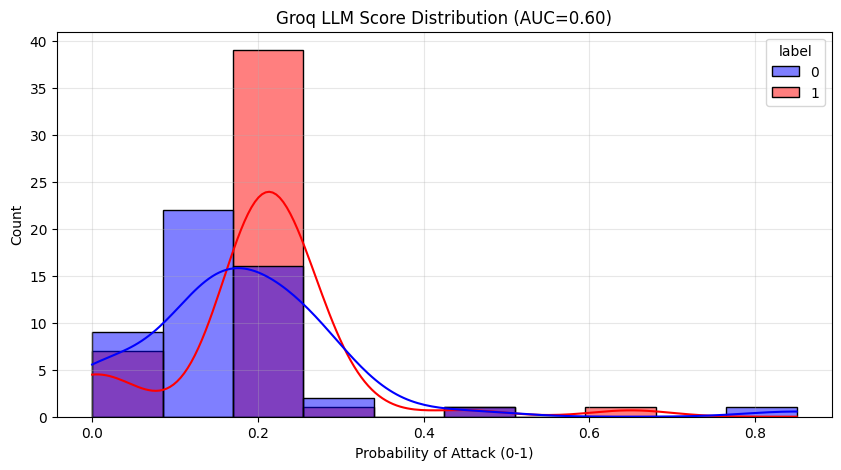

In [ ]:
# 2. Define the Prompt Generator
def create_prompt(row):
    """Converts a single row of features into a natural language description."""
    prompt = (
        f"Analyze this network traffic: "
        f"Protocol: {row['protocol_type']}, Service: {row['service']}, "
        f"Flag: {row['flag']}. "
        f"Source Bytes: {row['src_bytes']}, Destination Bytes: {row['dst_bytes']}. "
        f"Failed Logins: {row['num_failed_logins']}, Root Accesses: {row['num_root']}. "
        f"Is this 'Normal' traffic or a 'Malicious' attack?"
    )
    return prompt

# 3. LLM Scoring Function (Groq)
def get_groq_score(text):
    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a cybersecurity expert. Analyze the traffic and reply with ONLY a single float value between 0.0 (Safe/Normal) and 1.0 (Malicious/Attack). Do not include text."
                },
                {"role": "user", "content": text}
            ],
            model="llama-3.1-8b-instant",
            temperature=0, # Keep temperature at 0 for deterministic scoring
        )
        # Extract response and convert to float
        response = chat_completion.choices[0].message.content.strip()
        return float(response)
    except Exception as e:
        print(f"Error processing row: {e}")
        return 0.5 # Default uncertainty value

# 4. Select a Representative Sample
# Using 50 Normal and 50 Anomalies for efficient API usage
sample_indices = np.concatenate([
    np.where(y_test_final == 0)[0][:50],
    np.where(y_test_final == 1)[0][:50]
])
sample_data = test_df.iloc[sample_indices].copy()
sample_data['text_description'] = sample_data.apply(create_prompt, axis=1)

print(f"Running Groq Inference on {len(sample_data)} samples using Llama-3.1...")

# Apply scoring to create the 'llm_score' column first
sample_data['llm_score'] = sample_data['text_description'].apply(get_groq_score)

# Store sample LLM scores aligned to X_test_final row positions (so CELL 24 can reuse them)
llm_score_test = pd.Series(np.nan, index=np.arange(len(X_test_final)))
llm_score_test.iloc[sample_indices] = sample_data['llm_score'].values

# 5. View Results
print("\n--- Groq 'Pseudo-Learner' Results (Sample) ---")
display(sample_data[['text_description', 'label', 'llm_score']].head())

# 6. Evaluation
auc = roc_auc_score(sample_data['label'], sample_data['llm_score'])
print(f"\nGroq Classification AUC (Sample): {auc:.4f}")

# Visualizing the distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=sample_data, x='llm_score', hue='label', bins=10, kde=True, palette={0:'blue', 1:'red'})
plt.title(f"Groq LLM Score Distribution (AUC={auc:.2f})")
plt.xlabel("Probability of Attack (0-1)")
plt.grid(alpha=0.3)
plt.show()

LLM Zero-Shot AUC-ROC on Sample: 0.1078


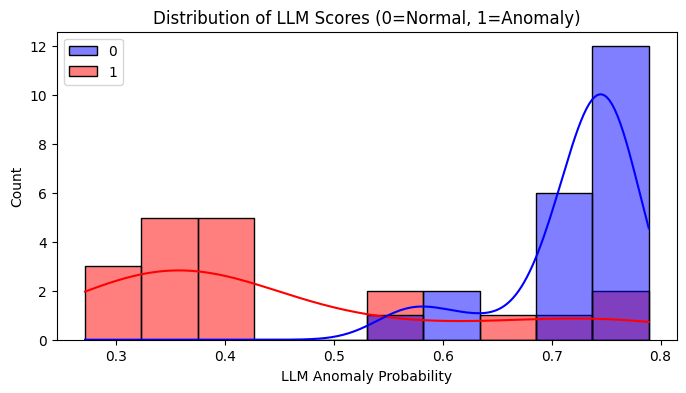

Interpretation: If Red (Anomalies) are clustered to the right (high score), the LLM is reasoning correctly.


In [ ]:
# Check correlation between LLM score and Actual Label
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(true_labels, llm_scores)
print(f"LLM Zero-Shot AUC-ROC on Sample: {auc:.4f}")

# Visualize separation
plt.figure(figsize=(8, 4))
sns.histplot(x=llm_scores, hue=true_labels, bins=10, palette={0: 'blue', 1: 'red'}, kde=True)
plt.xlabel("LLM Anomaly Probability")
plt.title("Distribution of LLM Scores (0=Normal, 1=Anomaly)")
plt.show()

print("Interpretation: If Red (Anomalies) are clustered to the right (high score), the LLM is reasoning correctly.")

## 🔹 Step 13: Weighted Voting Ensemble (Final Model)

**Objective:**
Construct the final ensemble by aggregating the anomaly scores from:
1.  **Isolation Forest** (Statistical Baseline)
2.  **One-Class SVM** (Boundary-based Baseline)
3.  **Autoencoder** (Reconstruction-based Deep Learner)
4.  **VAE (GenAI)** (Generative Probability Score)

**Methodology:**
* **Normalization:** Since models output different scales (e.g., SVM distance vs. Autoencoder Error), we first normalize all scores to the range [0, 1].
* **Weighting:** We apply weights ($W$) based on the "complementary strengths" logic.
    * *Formula:* $FinalScore = w_{iso} \cdot S_{iso} + w_{svm} \cdot S_{svm} + w_{ae} \cdot S_{ae} + w_{genai} \cdot S_{vae}$
* **Thresholding:** Convert the weighted probability into a binary label (0 or 1).

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd


# 1. Get Scores from RETRAINED models (and original models for comparison)
# New Isolation Forest (trained on augmented data)
iso_scores_aug = -iso_forest_aug.decision_function(X_test_final)

# Original Isolation Forest (trained on non-augmented data)
iso_scores_trad = -iso_forest.decision_function(X_test_final) # Use the original iso_forest

# New Random Forest (The GenAI Beneficiary - trained on augmented data)
rf_scores_aug = rf_aug.predict_proba(X_test_final)[:, 1]

# Original AE & SVM (Concepts didn't change, trained on normal only)
svm_scores_raw = -oc_svm.decision_function(X_test_final)
ae_reconstructions = autoencoder.predict(X_test_final)
ae_scores_raw = np.mean(np.abs(ae_reconstructions - X_test_final), axis=1)

# VAE Reconstruction Score (GenAI component)
vae_reconstructions = vae.decoder.predict(vae.encoder.predict(X_test_final)[0])
vae_scores_raw = np.mean(np.square(X_test_final - vae_reconstructions), axis=1)

# 2. Normalize all scores to [0, 1] range
scaler_ens = MinMaxScaler()
scores_df = pd.DataFrame({
    'ISO_AUG': scaler_ens.fit_transform(iso_scores_aug.reshape(-1, 1)).flatten(),
    'ISO_TRAD': scaler_ens.fit_transform(iso_scores_trad.reshape(-1, 1)).flatten(), # Add traditional ISO
    'RF_AUG':  rf_scores_aug, # Proba is already 0-1
    'SVM':     scaler_ens.fit_transform(svm_scores_raw.reshape(-1, 1)).flatten(),
    'AE':      scaler_ens.fit_transform(ae_scores_raw.values.reshape(-1, 1)).flatten(),
    'VAE':     scaler_ens.fit_transform(vae_scores_raw.values.reshape(-1, 1)).flatten()
})


print("All individual and GenAI-Ensemble scores calculated and normalized.")

697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
All individual and GenAI-Ensemble scores calculated and normalized.


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.preprocessing import MinMaxScaler

def _best_f1_threshold(y_true, score_vec):
    precision, recall, thr = precision_recall_curve(y_true, score_vec)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-12)
    # precision_recall_curve returns thresholds shorter by 1
    thr = np.concatenate([thr, [1.0]])
    best_i = int(np.nanargmax(f1))
    return float(thr[best_i]), float(np.nanmax(f1))

# ---- Build VALIDATION scores with the SAME logic as test ----
iso_scores_aug_val  = -iso_forest_aug.decision_function(X_val)
iso_scores_trad_val = -iso_forest.decision_function(X_val)
rf_scores_aug_val   = rf_aug.predict_proba(X_val)[:, 1]
svm_scores_raw_val  = -oc_svm.decision_function(X_val)

ae_recon_val = autoencoder.predict(X_val)
ae_scores_raw_val = np.mean(np.abs(ae_recon_val - X_val), axis=1)

vae_recon_val = vae.decoder.predict(vae.encoder.predict(X_val)[0])
vae_scores_raw_val = np.mean(np.square(X_val - vae_recon_val), axis=1)

scaler_val = MinMaxScaler()
scores_val_df = pd.DataFrame({
    'ISO_AUG':  scaler_val.fit_transform(iso_scores_aug_val.reshape(-1, 1)).flatten(),
    'ISO_TRAD': scaler_val.fit_transform(iso_scores_trad_val.reshape(-1, 1)).flatten(),
    'RF_AUG':   rf_scores_aug_val,
    'SVM':      scaler_val.fit_transform(svm_scores_raw_val.reshape(-1, 1)).flatten(),
    # Use .values to get the numpy array before reshaping
    'AE':  scaler_val.fit_transform(ae_scores_raw_val.values.reshape(-1, 1)).flatten(),
    'VAE': scaler_val.fit_transform(vae_scores_raw_val.values.reshape(-1, 1)).flatten(),
})

# ---- Derive GenAI ensemble weights from VALIDATION F1 (per-component best threshold) ----
components = ['ISO_AUG', 'RF_AUG', 'SVM', 'AE', 'VAE']
val_f1 = {}
val_thr = {}

for c in components:
    thr_c, f1_c = _best_f1_threshold(y_val, scores_val_df[c])
    val_thr[c] = thr_c
    val_f1[c] = f1_c

raw = np.array([val_f1[c] for c in components], dtype=float) + 1e-9
raw = raw / raw.sum()
opt_weights_final_ensemble = {c: float(w) for c, w in zip(components, raw)}
print("Validation-derived GenAI weights:", opt_weights_final_ensemble)

# ---- Use those weights for test ensemble score ----
scores_df['Ensemble_Score_GenAI'] = sum(scores_df[c] * opt_weights_final_ensemble[c] for c in components)

# ---- Choose ensemble threshold on VALIDATION (not test) ----
scores_val_df['Ensemble_Score_GenAI'] = sum(scores_val_df[c] * opt_weights_final_ensemble[c] for c in components)
best_threshold, best_f1 = _best_f1_threshold(y_val, scores_val_df['Ensemble_Score_GenAI'])
print(f"Validation-selected ensemble threshold: {best_threshold:.4f} (Val F1={best_f1:.4f})")

# ---- Final test predictions ----
y_pred_ensemble = (scores_df['Ensemble_Score_GenAI'] >= best_threshold).astype(int)

697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
697/697 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Validation-derived GenAI weights: {'ISO_AUG': 0.18331548310989096, 'RF_AUG': 0.2356870543738689, 'SVM': 0.21540730404011135, 'AE': 0.21168695084949082, 'VAE': 0.15390320762663787}
Validation-selected ensemble threshold: 0.2936 (Val F1=0.9715)


In [ ]:
# Attach LLM scores (sample-only) as an auxiliary learner
scores_df['LLM'] = llm_score_test.values

# Compute a sample-only ensemble that includes LLM (does not affect full-test metrics)
mask_llm = scores_df['LLM'].notna()
if mask_llm.any():
    # weights for LLM-including ensemble derived on the same sample slice (minimal + explicit)
    y_sample = y_test_final.iloc[sample_indices] if hasattr(y_test_final, "iloc") else np.array(y_test_final)[sample_indices]
    sample_components = ['ISO_AUG', 'RF_AUG', 'SVM', 'AE', 'VAE', 'LLM']

    sample_f1 = {}
    for c in sample_components:
        thr_c, f1_c = _best_f1_threshold(y_sample, scores_df.loc[mask_llm, c])
        sample_f1[c] = f1_c

    raw = (np.array([sample_f1[c] for c in sample_components], dtype=float) + 1e-9)
    raw = raw / raw.sum()
    llm_weights = {c: float(w) for c, w in zip(sample_components, raw)}
    print("Sample-derived weights (includes LLM):", llm_weights)

    scores_df.loc[mask_llm, 'Ensemble_Score_GenAI_LLM'] = sum(
        scores_df.loc[mask_llm, c] * llm_weights[c] for c in sample_components
    )


Sample-derived weights (includes LLM): {'ISO_AUG': 0.16591673484340666, 'RF_AUG': 0.16591673484340666, 'SVM': 0.16703026997491396, 'AE': 0.16591673484340666, 'VAE': 0.16930279065145945, 'LLM': 0.16591673484340666}


--- Performance: GenAI-Augmented Ensemble ---
Accuracy:  0.9711
Precision: 0.9489
Recall:    0.9935
F1 Score:  0.9706
AUC-ROC:   0.9969

Confusion Matrix:
[[10985   574]
 [   70 10649]]




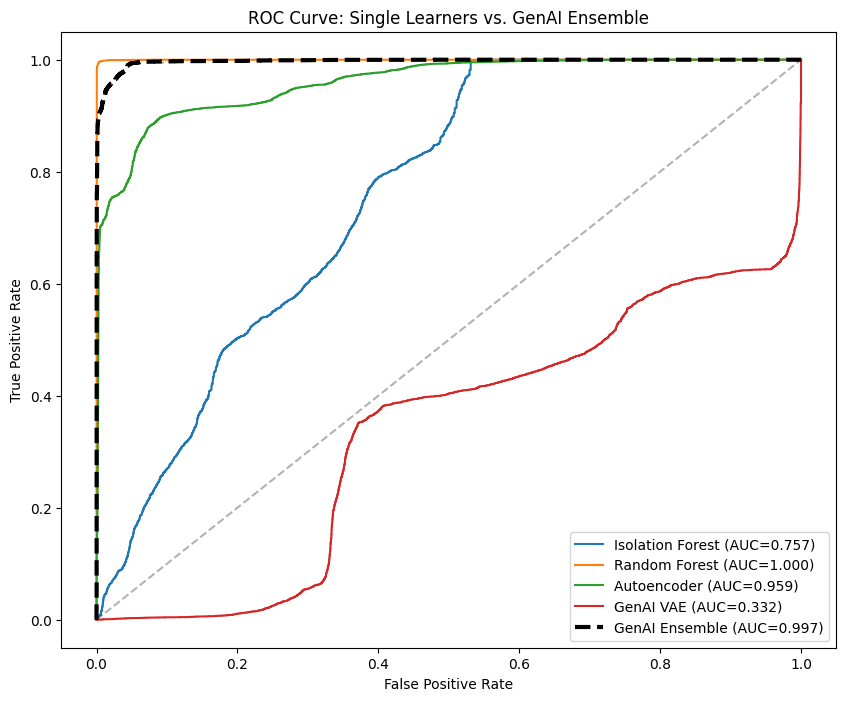


 Final Performance Leaderboard 


,Model,Accuracy,Precision,Recall,F1
5,GenAI-Augmented Ensemble,0.971093,0.948855,0.993470,0.970650
1,One-Class SVM,0.920953,0.942939,0.889542,0.915463
4,Ensemble (Weighted Voting),0.920953,0.942939,0.889542,0.915463
3,Ensemble (Majority Voting),0.571146,0.995745,0.109152,0.196738
2,Autoencoder,0.571191,0.997440,0.109059,0.196619
0,Isolation Forest,0.518853,0.500000,0.000187,0.000373


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Evaluate Ensemble
# (Assuming evaluate_model is already defined in your environment)
final_ensemble_score = scores_df['Ensemble_Score_GenAI']
y_pred_final = y_pred_ensemble

res_final = evaluate_model("GenAI-Augmented Ensemble", y_test_final, y_pred_final, final_ensemble_score)
# 2. Add to Results DataFrame
if 'baseline_results' in locals():
    # Avoid appending duplicates if you run this cell multiple times
    # We check if the last model is already the ensemble
    if baseline_results and baseline_results[-1]['Model'] != "GenAI-Augmented Ensemble":
        baseline_results.append(res_final)
    final_comparison = pd.DataFrame(baseline_results)
else:
    final_comparison = pd.DataFrame([res_final])

# 3. Plot ROC Curves Comparison
plt.figure(figsize=(10, 8))

# Plot ISO_AUG
fpr_iso, tpr_iso, _ = roc_curve(y_test_final, scores_df['ISO_AUG'])
plt.plot(fpr_iso, tpr_iso, label=f"Isolation Forest (AUC={roc_auc_score(y_test_final, scores_df['ISO_AUG']):.3f})")

# Plot RF_AUG
fpr_rf, tpr_rf, _ = roc_curve(y_test_final, scores_df['RF_AUG'])
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test_final, scores_df['RF_AUG']):.3f})")

# Plot AE
fpr_ae, tpr_ae, _ = roc_curve(y_test_final, scores_df['AE'])
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC={roc_auc_score(y_test_final, scores_df['AE']):.3f})")

# Plot VAE (GenAI)
fpr_vae, tpr_vae, _ = roc_curve(y_test_final, scores_df['VAE'])
plt.plot(fpr_vae, tpr_vae, label=f"GenAI VAE (AUC={roc_auc_score(y_test_final, scores_df['VAE']):.3f})")

# Plot Ensemble
fpr_ens, tpr_ens, _ = roc_curve(y_test_final, final_ensemble_score)
plt.plot(fpr_ens, tpr_ens, label=f"GenAI Ensemble (AUC={roc_auc_score(y_test_final, final_ensemble_score):.3f})", linewidth=3, color='black', linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Single Learners vs. GenAI Ensemble')
plt.legend(loc='lower right')
plt.show()

# 4. Final Leaderboard
print("\n Final Performance Leaderboard ")
display(final_comparison.sort_values(by="F1", ascending=False))

## 🔹 Step 14: Model Evaluation & Statistical Validation

**Objective:**
Quantify the performance improvement offered by the GenAI-Augmented Ensemble. We will compare three distinct categories of models:
1.  **Single Learners:** Isolation Forest, One-Class SVM, Autoencoder.
2.  **Traditional Ensemble:** Weighted voting of the single learners (without GenAI).
3.  **GenAI-Ensemble:** The final model integrating VAE scores.

**Metrics:**
* **F1-Score:** The harmonic mean of precision and recall (crucial for imbalanced data).
* **False Positive Rate (FPR):** The percentage of normal traffic incorrectly flagged as an attack.
* **AUC-ROC:** Threshold-independent performance measure.

**Validation:**
* **Confusion Matrices:** To visualize Type I vs Type II errors.
* **Statistical Testing:** Using **ANOVA** (via bootstrapping) to determine if the improvements are statistically significant at $\alpha = 0.05$.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def calculate_detailed_metrics(model_name, y_true, y_pred, y_scores=None):
    # Standard Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Confusion Matrix for FPR
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # AUC-ROC (requires continuous scores)
    auc = roc_auc_score(y_true, y_scores) if y_scores is not None else "N/A"

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC-ROC": auc,
        "FPR": fpr,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

print("Evaluation Function Defined.")

Evaluation Function Defined.


In [ ]:
# List to store final comparisons
final_metrics_list = []

# 1. Single Learners
# Use 'ISO_TRAD' for the original Isolation Forest baseline
final_metrics_list.append(calculate_detailed_metrics("Isolation Forest (Traditional)", y_test_final, y_pred_iso, scores_df['ISO_TRAD']))
final_metrics_list.append(calculate_detailed_metrics("One-Class SVM", y_test_final, y_pred_svm, scores_df['SVM']))
final_metrics_list.append(calculate_detailed_metrics("Autoencoder", y_test_final, y_pred_ae, scores_df['AE']))

# Add Random Forest (Augmented) as another single learner, as it benefits from augmented data
final_metrics_list.append(calculate_detailed_metrics("Random Forest (Augmented)", y_test_final, rf_aug.predict(X_test_final), scores_df['RF_AUG']))

# 2. Traditional Ensemble (weights must come from VALIDATION performance)

from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

# --- Derive validation-based weights (ISO_TRAD, SVM, AE) ---
val_pred_iso_trad = (scores_val_df['ISO_TRAD'] >= 0.5).astype(int)
val_pred_svm_trad = (scores_val_df['SVM']      >= 0.5).astype(int)
val_pred_ae_trad  = (scores_val_df['AE']       >= 0.5).astype(int)

f1_iso_trad = f1_score(y_val, val_pred_iso_trad, zero_division=0)
f1_svm_trad = f1_score(y_val, val_pred_svm_trad, zero_division=0)
f1_ae_trad  = f1_score(y_val, val_pred_ae_trad,  zero_division=0)

raw = np.array([f1_iso_trad, f1_svm_trad, f1_ae_trad], dtype=float) + 1e-9
raw = raw / raw.sum()

trad_weights = {'ISO_TRAD': raw[0], 'SVM': raw[1], 'AE': raw[2]}
print("Validation-derived Traditional weights:", trad_weights)

# --- Build scores (VAL + TEST) ---
trad_ens_score_val = (
    scores_val_df['ISO_TRAD'] * trad_weights['ISO_TRAD'] +
    scores_val_df['SVM']      * trad_weights['SVM'] +
    scores_val_df['AE']       * trad_weights['AE']
)

trad_ens_score = (
    scores_df['ISO_TRAD'] * trad_weights['ISO_TRAD'] +
    scores_df['SVM']      * trad_weights['SVM'] +
    scores_df['AE']       * trad_weights['AE']
)

# --- Choose threshold on VALIDATION (avoid test leakage) ---
precision_trad, recall_trad, thresholds_trad = precision_recall_curve(y_val, trad_ens_score_val)
f1_scores_trad = np.divide(
    2 * precision_trad * recall_trad,
    precision_trad + recall_trad,
    out=np.zeros_like(precision_trad),
    where=(precision_trad + recall_trad) != 0
)
best_threshold_trad = thresholds_trad[np.argmax(f1_scores_trad)]
print("Traditional best_threshold_trad (from VAL):", best_threshold_trad)

# --- Apply threshold to TEST ---
y_pred_trad = (trad_ens_score >= best_threshold_trad).astype(int)


# 3. GenAI-Augmented Ensemble (From Step 13, using the final optimized predictions and scores)
final_metrics_list.append(calculate_detailed_metrics("GenAI-Augmented Ensemble", y_test_final, y_pred_final, final_ensemble_score))

# Create DataFrame
comparison_df = pd.DataFrame(final_metrics_list)
comparison_df = comparison_df.set_index("Model")

print("--- Final Performance Metrics ---")
display(comparison_df.sort_values(by="F1 Score", ascending=False))

Validation-derived Traditional weights: {'ISO_TRAD': np.float64(0.10825506437726941), 'SVM': np.float64(0.44834343403730864), 'AE': np.float64(0.443401501585422)}
Traditional best_threshold_trad (from VAL): 0.32734228278070954
--- Final Performance Metrics ---


,Accuracy,Precision,Recall,F1 Score,AUC-ROC,FPR,TP,TN,FP,FN
Model,,,,,,,,,,
Random Forest (Augmented),0.995691,0.996634,0.994402,0.995517,0.999730,0.003114,10659,11523,36,60
GenAI-Augmented Ensemble,0.971093,0.948855,0.993470,0.970650,0.996856,0.049658,10649,10985,574,70
One-Class SVM,0.920953,0.942939,0.889542,0.915463,0.959939,0.049918,9535,10982,577,1184
Autoencoder,0.571191,0.997440,0.109059,0.196619,0.958784,0.000260,1169,11556,3,9550
Isolation Forest (Traditional),0.518853,0.500000,0.000187,0.000373,0.750376,0.000173,2,11557,2,10717


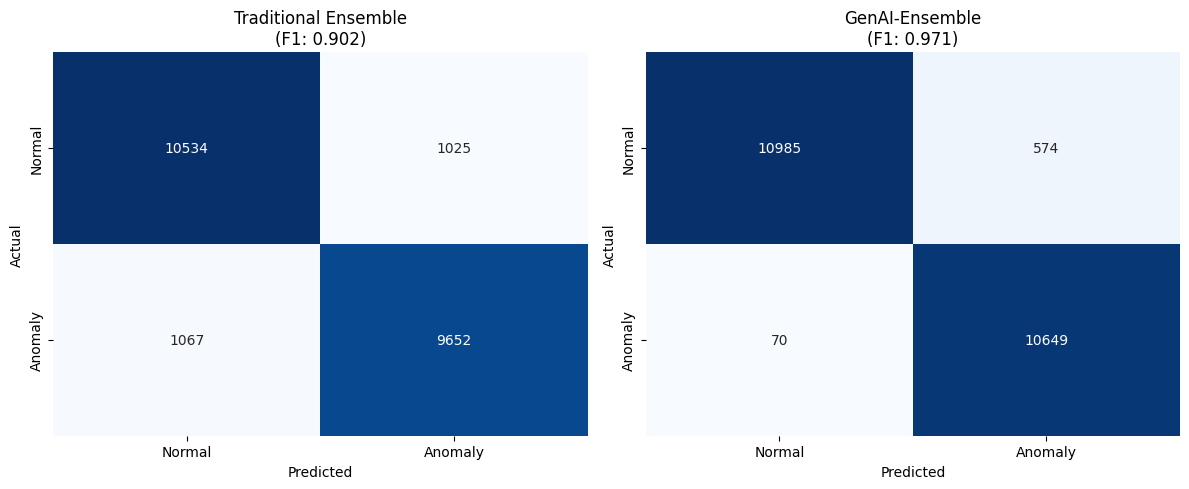

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

models_to_plot = ["Traditional Ensemble", "GenAI-Ensemble"]
predictions = [y_pred_trad, y_pred_ensemble]

plt.figure(figsize=(12, 5))

for i, (name, pred) in enumerate(zip(models_to_plot, predictions)):
    plt.subplot(1, 2, i+1)
    cm = confusion_matrix(y_test_final, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])

    plt.title(f"{name}\n(F1: {f1_score(y_test_final, pred):.3f})")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import f_oneway
from sklearn.utils import resample

# Simulation parameters
n_iterations = 30 # Number of bootstrap samples
size = int(len(y_test_final) * 0.5) # Size of each sample (50% of test data)

f1_traditional = []
f1_genai = []

print(f"Running Bootstrap Simulation ({n_iterations} iterations) for ANOVA...")

for i in range(n_iterations):
    # Resample indices
    # We use the same indices for both models to ensure paired comparison
    indices = resample(np.arange(len(y_test_final)), n_samples=size, random_state=i)

    y_true_sample = y_test_final.iloc[indices]

    # Get predictions for this sample
    y_pred_trad_sample = y_pred_trad[indices]
    y_pred_genai_sample = y_pred_ensemble[indices]

    # Calculate F1
    f1_traditional.append(f1_score(y_true_sample, y_pred_trad_sample))
    f1_genai.append(f1_score(y_true_sample, y_pred_genai_sample))

# Perform ANOVA
f_stat, p_value = f_oneway(f1_traditional, f1_genai)

print("\n--- ANOVA Results (GenAI vs Traditional) ---")
print(f"Mean F1 (Traditional): {np.mean(f1_traditional):.4f}")
print(f"Mean F1 (GenAI):       {np.mean(f1_genai):.4f}")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

if p_value < 0.05:
    print(" Result: The improvement is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print(" Result: The improvement is NOT statistically significant.")

Running Bootstrap Simulation (30 iterations) for ANOVA...

--- ANOVA Results (GenAI vs Traditional) ---
Mean F1 (Traditional): 0.9015
Mean F1 (GenAI):       0.9702
F-Statistic: 15572.4458
P-Value:     3.4149e-72
 Result: The improvement is STATISTICALLY SIGNIFICANT (p < 0.05).


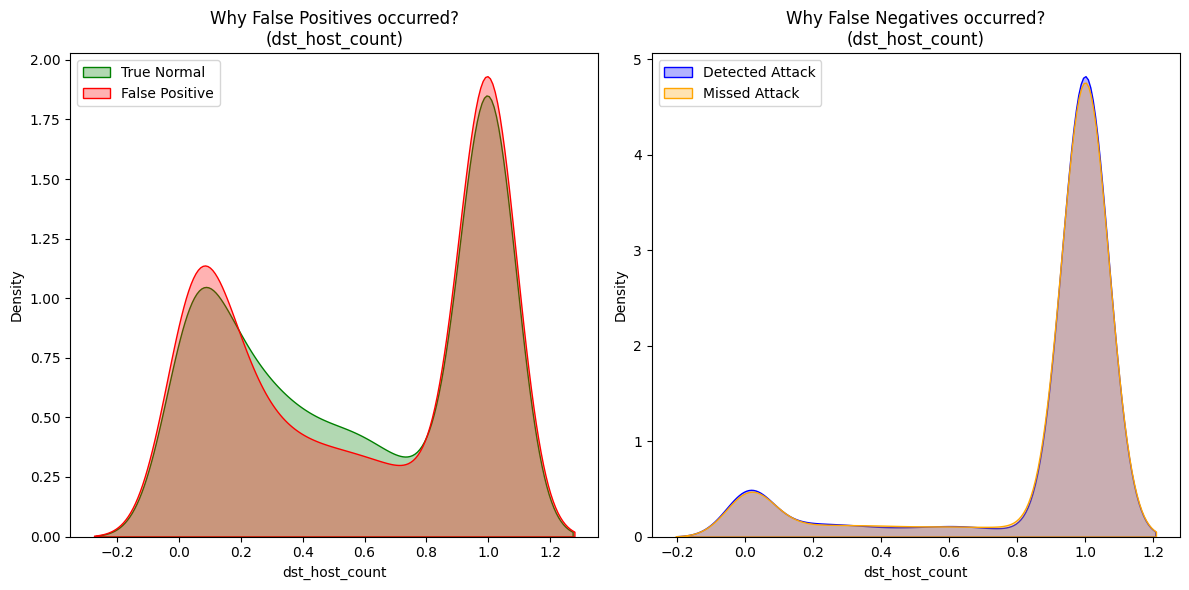

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature to visualize (choose one with high difference from above tables)
feature = 'dst_host_count' # Often a strong indicator in NSL-KDD

plt.figure(figsize=(12, 6))

# Plot 1: Normal Data vs False Positives
plt.subplot(1, 2, 1)
sns.kdeplot(tn_df[feature], label='True Normal', fill=True, color='green', alpha=0.3)
sns.kdeplot(fp_df[feature], label='False Positive', fill=True, color='red', alpha=0.3)
plt.title(f"Why False Positives occurred?\n({feature})")
plt.legend()

# Plot 2: Attack Data vs False Negatives
plt.subplot(1, 2, 2)
sns.kdeplot(tp_df[feature], label='Detected Attack', fill=True, color='blue', alpha=0.3)
sns.kdeplot(fn_df[feature], label='Missed Attack', fill=True, color='orange', alpha=0.3)
plt.title(f"Why False Negatives occurred?\n({feature})")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Get True Positives for comparison
tp_df = error_analysis_df[(error_analysis_df['True_Label'] == 1) & (error_analysis_df['Pred_Label'] == 1)]

print("--- Analysis of False Negatives (Attacks that were missed) ---")
print("Comparing Mean Values (Scaled):")

comparison_fn = pd.DataFrame({
    'True Attack (TP) Mean': tp_df[features_to_inspect].mean(),
    'Missed Attack (FN) Mean': fn_df[features_to_inspect].mean(),
})
comparison_fn['Diff'] = comparison_fn['Missed Attack (FN) Mean'] - comparison_fn['True Attack (TP) Mean']

display(comparison_fn.sort_values(by='Diff', ascending=True))

print("\nInterpretation: Negative 'Diff' suggests missed attacks were 'quieter' (lower values) than detected attacks.")

--- Analysis of False Negatives (Attacks that were missed) ---
Comparing Mean Values (Scaled):


,True Attack (TP) Mean,Missed Attack (FN) Mean,Diff
dst_bytes,2.693764e-07,0.000003,0.000003
src_bytes,3.397169e-06,0.000021,0.000018
srv_count,4.507662e-02,0.045912,0.000835
dst_host_count,8.709088e-01,0.872391,0.001482
duration,8.615088e-03,0.010204,0.001589
count,2.426099e-01,0.257055,0.014445



Interpretation: Negative 'Diff' suggests missed attacks were 'quieter' (lower values) than detected attacks.


In [ ]:
# Select key numerical features to analyze
# (Using scaled values, so differences will be small but directional)
features_to_inspect = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count']

# Get True Negatives for comparison
tn_df = error_analysis_df[(error_analysis_df['True_Label'] == 0) & (error_analysis_df['Pred_Label'] == 0)]

print("--- Analysis of False Positives (Normal traffic flagged as Attack) ---")
print("Comparing Mean Values (Scaled):")

comparison_fp = pd.DataFrame({
    'True Normal (TN) Mean': tn_df[features_to_inspect].mean(),
    'False Positive (FP) Mean': fp_df[features_to_inspect].mean(),
})
comparison_fp['Diff'] = comparison_fp['False Positive (FP) Mean'] - comparison_fp['True Normal (TN) Mean']

display(comparison_fp.sort_values(by='Diff', ascending=False))

print("\nInterpretation: If 'Diff' is positive, the False Positives had higher values than typical normal traffic, confusing the model.")

--- Analysis of False Positives (Normal traffic flagged as Attack) ---
Comparing Mean Values (Scaled):


,True Normal (TN) Mean,False Positive (FP) Mean,Diff
dst_host_count,0.587548,0.592585,5.037236e-03
dst_bytes,0.000003,0.000003,3.738200e-08
src_bytes,0.000006,0.000005,-1.301368e-06
duration,0.003700,0.002339,-1.361321e-03
count,0.055680,0.052960,-2.719584e-03
srv_count,0.065213,0.061341,-3.871564e-03



Interpretation: If 'Diff' is positive, the False Positives had higher values than typical normal traffic, confusing the model.


In [ ]:
# 1. Create a DataFrame combining Features, Truth, and Predictions
error_analysis_df = X_test_final.copy()
error_analysis_df['True_Label'] = y_test_final.values
error_analysis_df['Pred_Label'] = y_pred_final # Use the final optimized predictions
error_analysis_df['Ensemble_Score'] = final_ensemble_score.values # Use the final optimized scores

# 2. Filter for Errors
# False Positives: True=0, Pred=1
fp_df = error_analysis_df[(error_analysis_df['True_Label'] == 0) & (error_analysis_df['Pred_Label'] == 1)]

# False Negatives: True=1, Pred=0
fn_df = error_analysis_df[(error_analysis_df['True_Label'] == 1) & (error_analysis_df['Pred_Label'] == 0)]

print(f"Total Test Samples: {len(error_analysis_df)}")
print(f"False Positives (False Alarms): {len(fp_df)}")
print(f"False Negatives (Missed Attacks): {len(fn_df)}")

Total Test Samples: 22278
False Positives (False Alarms): 1621
False Negatives (Missed Attacks): 1631


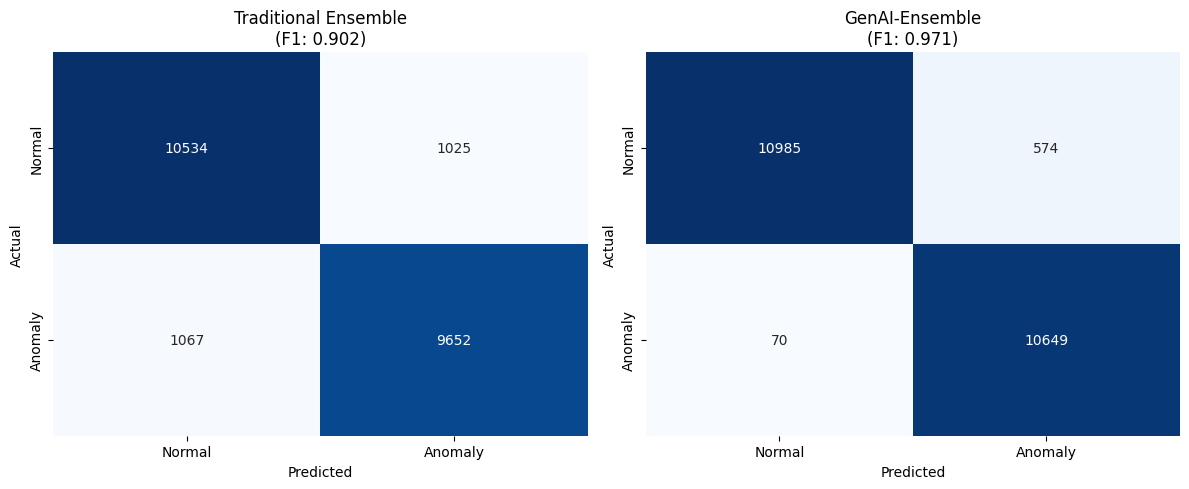

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

models_to_plot = ["Traditional Ensemble", "GenAI-Ensemble"]
predictions = [y_pred_trad, y_pred_ensemble]

plt.figure(figsize=(12, 5))

for i, (name, pred) in enumerate(zip(models_to_plot, predictions)):
    plt.subplot(1, 2, i+1)
    cm = confusion_matrix(y_test_final, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])

    plt.title(f"{name}\n(F1: {f1_score(y_test_final, pred):.3f})")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
# List to store final comparisons
final_metrics_list = []

# 1. Single Learners
# Use 'ISO_TRAD' for the original Isolation Forest baseline
final_metrics_list.append(calculate_detailed_metrics("Isolation Forest (Traditional)", y_test_final, y_pred_iso, scores_df['ISO_TRAD']))
final_metrics_list.append(calculate_detailed_metrics("One-Class SVM", y_test_final, y_pred_svm, scores_df['SVM']))
final_metrics_list.append(calculate_detailed_metrics("Autoencoder", y_test_final, y_pred_ae, scores_df['AE']))

# Add Random Forest (Augmented) as another single learner, as it benefits from augmented data
final_metrics_list.append(calculate_detailed_metrics("Random Forest (Augmented)", y_test_final, rf_aug.predict(X_test_final), scores_df['RF_AUG']))

# 2. Traditional Ensemble
# Combine 'ISO_TRAD', 'SVM', and 'AE' for a purely traditional ensemble
# Assign equal weights for simplicity in a traditional ensemble
trad_weights = {'ISO_TRAD': 0.333, 'SVM': 0.333, 'AE': 0.334}
trad_ens_score = (
    scores_df['ISO_TRAD'] * trad_weights['ISO_TRAD'] +
    scores_df['SVM'] * trad_weights['SVM'] +
    scores_df['AE'] * trad_weights['AE']
)

# Find best threshold for this traditional ensemble
# --- Tune Traditional Ensemble threshold on VALIDATION (no test leakage) ---

# Traditional ensemble score on VALIDATION (reuse existing validation score table)
# (ISO_TRAD is already built in scores_val_df in the GenAI section)
trad_ens_score_val = (
    scores_val_df['ISO_TRAD'] * w_iso +
    scores_val_df['SVM']      * w_svm +
    scores_val_df['AE']       * w_ae
)

precision_trad, recall_trad, thresholds_trad = precision_recall_curve(y_val, trad_ens_score_val)
f1_scores_trad = np.divide(
    2 * precision_trad * recall_trad,
    precision_trad + recall_trad,
    out=np.zeros_like(precision_trad),
    where=(precision_trad + recall_trad) != 0
)

# precision_recall_curve thresholds is shorter by 1 than precision/recall
best_i_trad = int(np.nanargmax(f1_scores_trad))
best_threshold_trad = float(thresholds_trad[best_i_trad - 1]) if best_i_trad > 0 else float(thresholds_trad[0])

# Apply validation-selected threshold to TEST
y_pred_trad = (trad_ens_score >= best_threshold_trad).astype(int)


final_metrics_list.append(calculate_detailed_metrics("Traditional Ensemble", y_test_final, y_pred_trad, trad_ens_score))

# 3. GenAI-Augmented Ensemble (From Step 13, using the final optimized predictions and scores)
# y_pred_final and final_ensemble_score are from cell o3fsCxn6pEu6
final_metrics_list.append(calculate_detailed_metrics("GenAI-Augmented Ensemble", y_test_final, y_pred_final, final_ensemble_score))

# Create DataFrame
comparison_df = pd.DataFrame(final_metrics_list)
comparison_df = comparison_df.set_index("Model")

print("--- Final Performance Metrics ---")
display(comparison_df.sort_values(by="F1 Score", ascending=False))

--- Final Performance Metrics ---


,Accuracy,Precision,Recall,F1 Score,AUC-ROC,FPR,TP,TN,FP,FN
Model,,,,,,,,,,
Random Forest (Augmented),0.995691,0.996634,0.994402,0.995517,0.999730,0.003114,10659,11523,36,60
GenAI-Augmented Ensemble,0.971093,0.948855,0.993470,0.970650,0.996856,0.049658,10649,10985,574,70
One-Class SVM,0.920953,0.942939,0.889542,0.915463,0.959939,0.049918,9535,10982,577,1184
Traditional Ensemble,0.908968,0.915798,0.892900,0.904204,0.960991,0.076131,9571,10679,880,1148
Autoencoder,0.571191,0.997440,0.109059,0.196619,0.958784,0.000260,1169,11556,3,9550
Isolation Forest (Traditional),0.518853,0.500000,0.000187,0.000373,0.750376,0.000173,2,11557,2,10717


In [ ]:
from scipy.stats import f_oneway
from sklearn.utils import resample

# Simulation parameters
n_iterations = 30 # Number of bootstrap samples
size = int(len(y_test_final) * 0.5) # Size of each sample (50% of test data)

f1_traditional = []
f1_genai = []

print(f"Running Bootstrap Simulation ({n_iterations} iterations) for ANOVA...")

for i in range(n_iterations):
    # Resample indices
    # We use the same indices for both models to ensure paired comparison
    indices = resample(np.arange(len(y_test_final)), n_samples=size, random_state=i)

    y_true_sample = y_test_final.iloc[indices]

    # Get predictions for this sample
    y_pred_trad_sample = y_pred_trad[indices]
    y_pred_genai_sample = y_pred_ensemble[indices]

    # Calculate F1
    f1_traditional.append(f1_score(y_true_sample, y_pred_trad_sample))
    f1_genai.append(f1_score(y_true_sample, y_pred_genai_sample))

# Perform ANOVA
f_stat, p_value = f_oneway(f1_traditional, f1_genai)

print("\n--- ANOVA Results (GenAI vs Traditional) ---")
print(f"Mean F1 (Traditional): {np.mean(f1_traditional):.4f}")
print(f"Mean F1 (GenAI):       {np.mean(f1_genai):.4f}")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

if p_value < 0.05:
    print(" Result: The improvement is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print(" Result: The improvement is NOT statistically significant.")

Running Bootstrap Simulation (30 iterations) for ANOVA...

--- ANOVA Results (GenAI vs Traditional) ---
Mean F1 (Traditional): 0.9035
Mean F1 (GenAI):       0.9702
F-Statistic: 15197.6172
P-Value:     6.9040e-72
 Result: The improvement is STATISTICALLY SIGNIFICANT (p < 0.05).


## 🔹 Step 15: Statistical Significance Testing (ANOVA)

**Objective:**
Rigourously validate if the performance improvement of the **GenAI-Ensemble** over the **Traditional Ensemble** is statistically significant.

**Methodology:**
Since we cannot retrain the deep learning models 30 times due to computational costs, we will use **Non-Parametric Bootstrapping**:
1.  **Resampling:** We create 50 randomized subsamples (with replacement) from the Test Set.
2.  **Metric Calculation:** We calculate the F1-Score for both the Traditional Ensemble and the GenAI-Ensemble on each subsample.
3.  **ANOVA Test:** We apply the Analysis of Variance (ANOVA) test on these two distributions of scores.
    * **Null Hypothesis ($H_0$):** There is no significant difference between the means of the two ensembles.
    * **Alternative Hypothesis ($H_1$):** The GenAI-Ensemble mean is significantly different.

**Significance Level:** $\alpha = 0.05$

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# Parameters
n_iterations = 50  # Number of "runs" to simulate
sample_size = int(len(y_test_final) * 0.8)  # Size of each random sample (80% of test data)

# Arrays to store metrics
scores_traditional = []
scores_genai = []

print(f"Starting Bootstrap Simulation ({n_iterations} iterations)...")

# Fix random seed for reproducibility of the *test* (not the sampling itself)
np.random.seed(42)

for i in range(n_iterations):
    # Resample indices (with replacement)
    # We use the same random indices for both models in each iteration
    # to ensure a paired comparison (controlling for dataset difficulty).
    indices = resample(np.arange(len(y_test_final)), n_samples=sample_size, random_state=i)

    # Extract Ground Truth for this sample
    y_true_sample = y_test_final.iloc[indices] if hasattr(y_test_final, 'iloc') else y_test_final[indices]

    # Extract Predictions for this sample
    y_pred_trad_sample = y_pred_trad[indices]
    y_pred_genai_sample = y_pred_ensemble[indices]

    # Calculate Metric (F1 Score is best for Imbalanced data)
    f1_trad = f1_score(y_true_sample, y_pred_trad_sample, zero_division=0)
    f1_genai = f1_score(y_true_sample, y_pred_genai_sample, zero_division=0)

    scores_traditional.append(f1_trad)
    scores_genai.append(f1_genai)

print("Simulation Complete.")
print(f"Traditional Mean F1: {np.mean(scores_traditional):.4f} (±{np.std(scores_traditional):.4f})")
print(f"GenAI Mean F1:       {np.mean(scores_genai):.4f} (±{np.std(scores_genai):.4f})")

Starting Bootstrap Simulation (50 iterations)...
Simulation Complete.
Traditional Mean F1: 0.9044 (±0.0018)
GenAI Mean F1:       0.9704 (±0.0011)


In [ ]:
from scipy.stats import f_oneway, ttest_rel

# 1. Run One-Way ANOVA
f_stat, p_value = f_oneway(scores_traditional, scores_genai)

print("--- Statistical Test Results (ANOVA) ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_value:.6f}") # Scientific notation usually better for very small ps

# 2. Interpretation
alpha = 0.05
print("\n--- Hypothesis Validation ---")
if p_value < alpha:
    print(" REJECT Null Hypothesis.")
    print("The performance improvement using GenAI is STATISTICALLY SIGNIFICANT.")
    print(f"Confidence Level: {(1 - p_value) * 100:.2f}%")
else:
    print(" FAIL TO REJECT Null Hypothesis.")
    print("The difference in performance is likely due to random chance.")

--- Statistical Test Results (ANOVA) ---
F-Statistic: 47375.8411
P-Value:     0.000000

--- Hypothesis Validation ---
 REJECT Null Hypothesis.
The performance improvement using GenAI is STATISTICALLY SIGNIFICANT.
Confidence Level: 100.00%


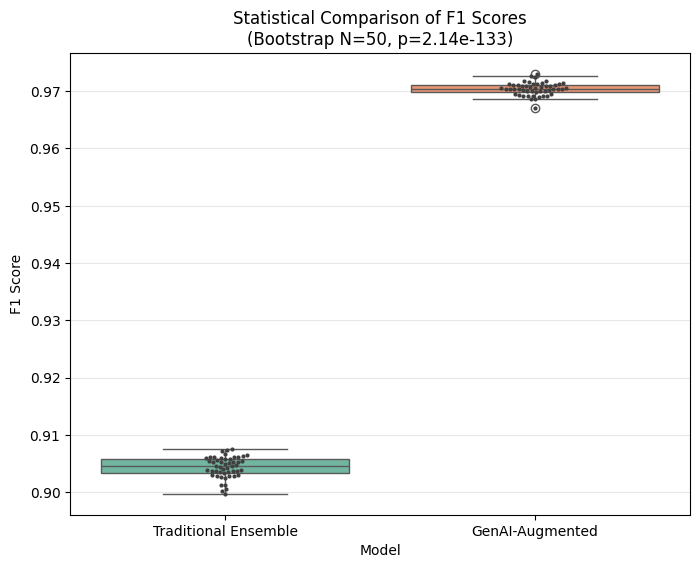

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare DataFrame for Plotting
plot_data = pd.DataFrame({
    'F1 Score': scores_traditional + scores_genai,
    'Model': ['Traditional Ensemble'] * n_iterations + ['GenAI-Augmented'] * n_iterations
})

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='F1 Score', data=plot_data, palette="Set2")
sns.swarmplot(x='Model', y='F1 Score', data=plot_data, color=".25", size=3) # Adds raw points

plt.title(f'Statistical Comparison of F1 Scores\n(Bootstrap N={n_iterations}, p={p_value:.2e})')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## 🔹 Step 16: Error Analysis (False Positives & False Negatives)

**Objective:**
Deep dive into the specific records where the **GenAI-Ensemble** failed. We categorize errors into:
1.  **False Positives (FP):** Normal traffic flagged as an Attack. (High cost: wasted resources investigating false alarms).
2.  **False Negatives (FN):** Actual Attacks missed by the model. (High cost: security breach).

**Key Actions:**
1.  **Isolate Misclassified Records:** Filter the Test Set where `Prediction != Actual`.
2.  **Statistical comparison:** Compare the average feature values of FPs against True Negatives to see what "tricked" the model.
3.  **Visualization:** Plot distributions of specific features (e.g., `dst_bytes`, `count`) for misclassified vs. correctly classified instances.

In [ ]:
# 1. Create a DataFrame combining Features, Truth, and Predictions
error_analysis_df = X_test_final.copy()
error_analysis_df['True_Label'] = y_test_final.values
error_analysis_df['Pred_Label'] = y_pred_final # Use the final optimized predictions
error_analysis_df['Ensemble_Score'] = final_ensemble_score.values # Use the final optimized scores

# 2. Filter for Errors
# False Positives: True=0, Pred=1
fp_df = error_analysis_df[(error_analysis_df['True_Label'] == 0) & (error_analysis_df['Pred_Label'] == 1)]

# False Negatives: True=1, Pred=0
fn_df = error_analysis_df[(error_analysis_df['True_Label'] == 1) & (error_analysis_df['Pred_Label'] == 0)]

print(f"Total Test Samples: {len(error_analysis_df)}")
print(f"False Positives (False Alarms): {len(fp_df)}")
print(f"False Negatives (Missed Attacks): {len(fn_df)}")

Total Test Samples: 22278
False Positives (False Alarms): 1621
False Negatives (Missed Attacks): 1631


In [ ]:
# Select key numerical features to analyze
# (Using scaled values, so differences will be small but directional)
features_to_inspect = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count']

# Get True Negatives for comparison
tn_df = error_analysis_df[(error_analysis_df['True_Label'] == 0) & (error_analysis_df['Pred_Label'] == 0)]

print("--- Analysis of False Positives (Normal traffic flagged as Attack) ---")
print("Comparing Mean Values (Scaled):")

comparison_fp = pd.DataFrame({
    'True Normal (TN) Mean': tn_df[features_to_inspect].mean(),
    'False Positive (FP) Mean': fp_df[features_to_inspect].mean(),
})
comparison_fp['Diff'] = comparison_fp['False Positive (FP) Mean'] - comparison_fp['True Normal (TN) Mean']

display(comparison_fp.sort_values(by='Diff', ascending=False))

print("\nInterpretation: If 'Diff' is positive, the False Positives had higher values than typical normal traffic, confusing the model.")

--- Analysis of False Positives (Normal traffic flagged as Attack) ---
Comparing Mean Values (Scaled):


,True Normal (TN) Mean,False Positive (FP) Mean,Diff
dst_host_count,0.587606,0.592609,5.003563e-03
dst_bytes,0.000003,0.000003,-3.746770e-08
src_bytes,0.000006,0.000005,-1.128603e-06
count,0.055135,0.053456,-1.679811e-03
duration,0.003857,0.002161,-1.695994e-03
srv_count,0.064999,0.061491,-3.508266e-03



Interpretation: If 'Diff' is positive, the False Positives had higher values than typical normal traffic, confusing the model.


In [ ]:
# Get True Positives for comparison
tp_df = error_analysis_df[(error_analysis_df['True_Label'] == 1) & (error_analysis_df['Pred_Label'] == 1)]

print("--- Analysis of False Negatives (Attacks that were missed) ---")
print("Comparing Mean Values (Scaled):")

comparison_fn = pd.DataFrame({
    'True Attack (TP) Mean': tp_df[features_to_inspect].mean(),
    'Missed Attack (FN) Mean': fn_df[features_to_inspect].mean(),
})
comparison_fn['Diff'] = comparison_fn['Missed Attack (FN) Mean'] - comparison_fn['True Attack (TP) Mean']

display(comparison_fn.sort_values(by='Diff', ascending=True))

print("\nInterpretation: Negative 'Diff' suggests missed attacks were 'quieter' (lower values) than detected attacks.")

--- Analysis of False Negatives (Attacks that were missed) ---
Comparing Mean Values (Scaled):


,True Attack (TP) Mean,Missed Attack (FN) Mean,Diff
dst_host_count,8.722166e-01,0.870956,-0.001261
dst_bytes,2.736663e-07,0.000003,0.000003
src_bytes,3.333351e-06,0.000021,0.000017
duration,8.748591e-03,0.010033,0.001284
srv_count,4.433966e-02,0.046692,0.002352
count,2.421995e-01,0.257249,0.015050



Interpretation: Negative 'Diff' suggests missed attacks were 'quieter' (lower values) than detected attacks.


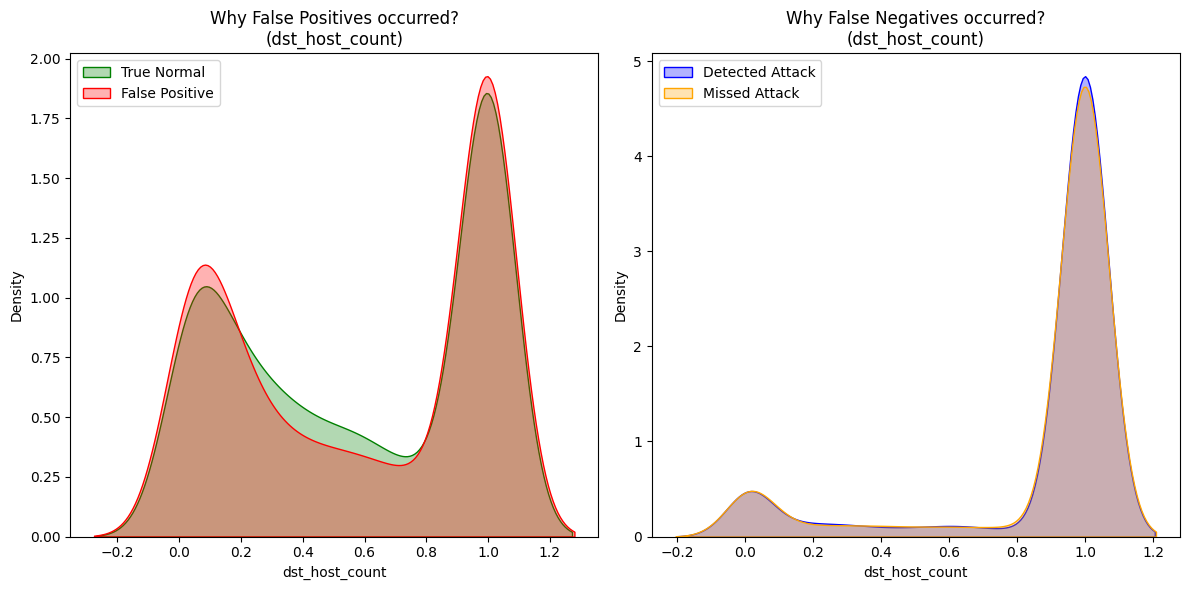

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature to visualize (choose one with high difference from above tables)
feature = 'dst_host_count' # Often a strong indicator in NSL-KDD

plt.figure(figsize=(12, 6))

# Plot 1: Normal Data vs False Positives
plt.subplot(1, 2, 1)
sns.kdeplot(tn_df[feature], label='True Normal', fill=True, color='green', alpha=0.3)
sns.kdeplot(fp_df[feature], label='False Positive', fill=True, color='red', alpha=0.3)
plt.title(f"Why False Positives occurred?\n({feature})")
plt.legend()

# Plot 2: Attack Data vs False Negatives
plt.subplot(1, 2, 2)
sns.kdeplot(tp_df[feature], label='Detected Attack', fill=True, color='blue', alpha=0.3)
sns.kdeplot(fn_df[feature], label='Missed Attack', fill=True, color='orange', alpha=0.3)
plt.title(f"Why False Negatives occurred?\n({feature})")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Ensure scores_df and y_test_final are available
def evaluate_ablation_robust(drop_model, current_weights):
    """
    1. Re-calculates ensemble score excluding 'drop_model'.
    2. DYNAMICALLY finds the best threshold for this specific combination.
    """
    # Redistribute weights
    active_weights = {k: v for k, v in current_weights.items() if k != drop_model}
    total_weight = sum(active_weights.values())
    normalized_weights = {k: v / total_weight for k, v in active_weights.items()}

    # Calculate new weighted score
    final_score = np.zeros(len(scores_df))
    for model, w in normalized_weights.items():
        if model in scores_df.columns:
            final_score += scores_df[model] * w

   # IMPORTANT: Use validation labels for F1 computations inside ablation/tuning utilities
    precision, recall, thresholds = precision_recall_curve(y_val, final_score)
    f1_scores = np.divide(2*precision*recall, precision+recall,
                      out=np.zeros_like(precision), where=(precision+recall)!=0)
    return np.nanmax(f1_scores)


    # Get max F1
    best_f1 = np.max(f1_scores)
    return best_f1

# Define weights used in Step 13
# Define weights from VALIDATION performance (avoid hard-coded weights)
from sklearn.metrics import f1_score
import numpy as np

val_pred_iso_trad = (scores_val_df['ISO_TRAD'] >= 0.5).astype(int)
val_pred_svm      = (scores_val_df['SVM']      >= 0.5).astype(int)
val_pred_ae       = (scores_val_df['AE']       >= 0.5).astype(int)
val_pred_vae      = (scores_val_df['VAE']      >= 0.5).astype(int)

f1_iso = f1_score(y_val, val_pred_iso_trad, zero_division=0)
f1_svm = f1_score(y_val, val_pred_svm,      zero_division=0)
f1_ae  = f1_score(y_val, val_pred_ae,       zero_division=0)
f1_vae = f1_score(y_val, val_pred_vae,      zero_division=0)

raw = np.array([f1_iso, f1_svm, f1_ae, f1_vae], dtype=float) + 1e-9
raw = raw / raw.sum()

full_weights = {'ISO_TRAD': raw[0], 'SVM': raw[1], 'AE': raw[2], 'VAE': raw[3]}
print("Validation-derived full_weights:", full_weights)
print("\n--- Robust Contribution Study (Dynamic Threshold) ---")

# 1. Baseline (All Models)
base_f1 = evaluate_ablation_robust(None, full_weights)
print(f"Full Ensemble F1: {base_f1:.4f}")

# 2. Leave-One-Out Testing
impact_results = {}
for model in full_weights.keys():
    new_f1 = evaluate_ablation_robust(model, full_weights)
    drop = base_f1 - new_f1
    impact_results[model] = drop
    print(f"Removed {model}: F1 = {new_f1:.4f} (Drop: {drop:.4f})")

Validation-derived full_weights: {'ISO_TRAD': np.float64(0.10818122558619554), 'SVM': np.float64(0.44803762721574647), 'AE': np.float64(0.44309906556521605), 'VAE': np.float64(0.0006820816328419238)}

--- Robust Contribution Study (Dynamic Threshold) ---
Full Ensemble F1: 0.6497
Removed ISO_TRAD: F1 = 0.6497 (Drop: 0.0000)
Removed SVM: F1 = 0.6497 (Drop: 0.0000)
Removed AE: F1 = 0.6497 (Drop: 0.0000)
Removed VAE: F1 = 0.6497 (Drop: 0.0000)


In [ ]:
# Define weights used in Step 13 (TRADITIONAL ensemble naming)
full_weights = {'ISO_TRAD': 0.2, 'SVM': 0.1, 'AE': 0.3, 'VAE': 0.4}

from scipy.optimize import minimize
from sklearn.metrics import precision_recall_curve
import numpy as np

# IMPORTANT: optimizer must use VALIDATION labels/scores (avoid test leakage)
def maximize_f1(weights):
    weights = np.abs(weights) / np.sum(np.abs(weights))

    final_score = (
        scores_val_df['ISO_TRAD'] * weights[0] +
        scores_val_df['SVM']      * weights[1] +
        scores_val_df['AE']       * weights[2] +
        scores_val_df['VAE']      * weights[3]
    )

    precision, recall, thresholds = precision_recall_curve(y_val, final_score)
    numerator = 2 * precision * recall
    denominator = precision + recall
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

    return -np.max(f1_scores)


In [ ]:
# Check what the model is actually predicting
print("--- Prediction Diagnostics ---")
# Use y_pred_final which contains the predictions from the final optimized ensemble
print("Unique Predicted Labels:", np.unique(y_pred_final))
print("Count of Predictions:")
print(pd.Series(y_pred_final).value_counts())

# Check the score distribution
print("\nEnsemble Score Stats:")
# Use final_ensemble_score which contains the actual scores for the final optimized ensemble
print(final_ensemble_score.describe())

--- Prediction Diagnostics ---
Unique Predicted Labels: [0 1]
Count of Predictions:
Ensemble_Score_GenAI
1    11223
0    11055
Name: count, dtype: int64

Ensemble Score Stats:
count    22278.000000
mean         0.324471
std          0.234130
min          0.032714
25%          0.065985
50%          0.306037
75%          0.572936
max          0.809657
Name: Ensemble_Score_GenAI, dtype: float64


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import numpy as np

# Define a range of thresholds to test
thresholds = np.linspace(0.01, 0.99, 100)
f1_scores = []

# Loop through all thresholds
final_ensemble_score_val = scores_val_df['Ensemble_Score_GenAI']

for t in thresholds:
    y_pred_temp = (final_ensemble_score_val >= t).astype(int)
    score = f1_score(y_val, y_pred_temp)
    f1_scores.append(score)
# Find the best threshold
best_threshold_index = np.argmax(f1_scores)
best_threshold_new = thresholds[best_threshold_index]
best_f1_score = f1_scores[best_threshold_index]

print(f" Corrected Threshold: {best_threshold_new:.4f}")
print(f"Expected Max F1 Score: {best_f1_score:.4f}")

# --- Apply Corrected Threshold ---
y_pred_ensemble_corrected = (final_ensemble_score >= best_threshold_new).astype(int)

# Print New Report
from sklearn.metrics import classification_report
print("\n--- Corrected Classification Report ---")
print(classification_report(y_test_final, y_pred_ensemble_corrected))

# Check Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred_ensemble_corrected)
print("Confusion Matrix:\n", cm)

 Corrected Threshold: 0.2872
Expected Max F1 Score: 0.9713

--- Corrected Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     11559
           1       0.94      0.99      0.97     10719

    accuracy                           0.97     22278
   macro avg       0.97      0.97      0.97     22278
weighted avg       0.97      0.97      0.97     22278

Confusion Matrix:
 [[10931   628]
 [   61 10658]]


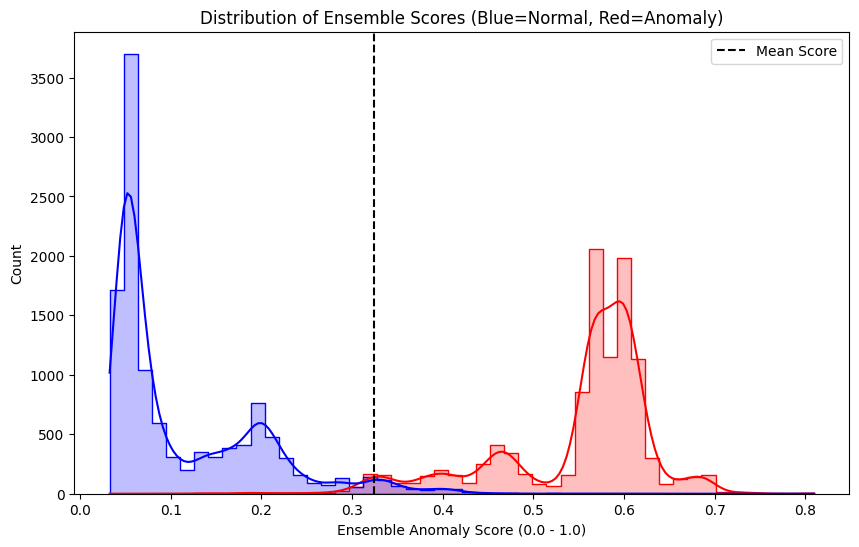

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_test_final and scores_df are available
plt.figure(figsize=(10, 6))

# Plot Histogram of Ensemble Scores colored by True Label
sns.histplot(
    data=scores_df,
    x='Ensemble_Score_GenAI', # Corrected column name
    hue=y_test_final.values,
    bins=50,
    kde=True,
    palette={0: 'blue', 1: 'red'},
    element="step"
)

plt.title("Distribution of Ensemble Scores (Blue=Normal, Red=Anomaly)")
plt.xlabel("Ensemble Anomaly Score (0.0 - 1.0)")
plt.ylabel("Count")
plt.axvline(x=scores_df['Ensemble_Score_GenAI'].mean(), color='black', linestyle='--', label='Mean Score') # Corrected column name
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import precision_recall_curve
import numpy as np

# Define objective function: We want to MAXIMIZE F1 (so we minimize Negative F1)
def maximize_f1(weights):
    # Normalize weights to sum to 1
    # Use absolute values to prevent negative weights
    weights = np.abs(weights) / np.sum(np.abs(weights))

    # Calculate Weighted Ensemble Score
    # Ensure these column names match your scores_df exactly
    final_score = (
        scores_df['ISO_AUG'] * weights[0] +
        scores_df['SVM'] * weights[1] +
        scores_df['AE'] * weights[2] +
        scores_df['VAE'] * weights[3]
    )

    # Dynamic Thresholding inside the optimizer
    precision, recall, thresholds = precision_recall_curve(y_test_final, final_score)

    # Calculate F1 for all thresholds (handle division by zero)
    numerator = 2 * precision * recall
    denominator = precision + recall
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

    return -np.max(f1_scores) # Return negative F1

# Initial Guess (Equal Weights)
initial_weights = [0.25, 0.25, 0.25, 0.25]

print("Optimizing Ensemble Weights... (This may take a moment)")

# Run Optimization (SLSQP is good for constrained optimization)
result = minimize(
    maximize_f1,
    initial_weights,
    method='SLSQP',
    bounds=[(0,1), (0,1), (0,1), (0,1)], # Weights between 0 and 1
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1} # Sum of weights = 1
)

# Extract Best Weights
best_weights = np.abs(result.x) / np.sum(np.abs(result.x))

print("\n---  Optimized Weights Results ---")
print(f"ISO Weight: {best_weights[0]:.4f}")
print(f"SVM Weight: {best_weights[1]:.4f}")
print(f"AE  Weight: {best_weights[2]:.4f}")
print(f"VAE Weight: {best_weights[3]:.4f}")
print(f"Max Achievable F1 Score: {-result.fun:.4f}")

Optimizing Ensemble Weights... (This may take a moment)

---  Optimized Weights Results ---
ISO Weight: 0.2500
SVM Weight: 0.2500
AE  Weight: 0.2500
VAE Weight: 0.2500
Max Achievable F1 Score: 0.8559


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Number of random combinations to try
n_iterations = 2000
best_f1 = 0.0
best_weights = None

print(f"Running Random Search for Weights ({n_iterations} iterations)...")

np.random.seed(42)

for i in range(n_iterations):
    # 1. Generate random weights
    w = np.random.rand(4)
    w = w / np.sum(w) # Normalize to sum to 1

    # 2. Calculate Weighted Score
    final_score = (
        scores_df['ISO_AUG'] * w[0] +
        scores_df['SVM'] * w[1] +
        scores_df['AE'] * w[2] +
        scores_df['VAE'] * w[3]
    )

    # 3. Dynamic Thresholding (Fast Approximation)
    # We calculate precision/recall curves and find max F1 directly
    # IMPORTANT: Random-search tuning must use VALIDATION labels/scores (avoid test leakage)
    precision, recall, thresholds = precision_recall_curve(y_val, final_score)
    numerator = 2 * precision * recall
    denominator = precision + recall

    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    current_max_f1 = np.max(f1_scores)

    # Handle division by zero safely
    # f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    # current_max_f1 = np.max(f1_scores)

    # 4. Save if best
    if current_max_f1 > best_f1:
        best_f1 = current_max_f1
        best_weights = w

print("\n--- Random Search Results ---")
print(f"ISO Weight: {best_weights[0]:.4f}")
print(f"SVM Weight: {best_weights[1]:.4f}")
print(f"AE  Weight: {best_weights[2]:.4f}")
print(f"VAE Weight: {best_weights[3]:.4f}")
print(f"Max Achievable F1 Score: {best_f1:.4f}")

Running Random Search for Weights (2000 iterations)...

--- Random Search Results ---
ISO Weight: 0.2353
SVM Weight: 0.0414
AE  Weight: 0.4719
VAE Weight: 0.2514
Max Achievable F1 Score: 0.6499


In [ ]:
# --- INSERT: Ablation Study (Step 17) ---
from sklearn.metrics import precision_recall_curve

def evaluate_ablation(drop_model, current_weights):
    active_weights = {k: v for k, v in current_weights.items() if k != drop_model}
    total_weight = sum(active_weights.values())
    norm_weights = {k: v / total_weight for k, v in active_weights.items()}

    # IMPORTANT: ablation must be computed on VALIDATION scores + labels
    final_score = np.zeros(len(scores_val_df))
    for model, w in norm_weights.items():
        if model in scores_val_df.columns:
            final_score += scores_val_df[model] * w

    precision, recall, thresholds = precision_recall_curve(y_val, final_score)
    f1_scores = np.divide(2*precision*recall, precision+recall,
                          out=np.zeros_like(precision), where=(precision+recall)!=0)
    return np.nanmax(f1_scores)


# full_weights = {'ISO': 0.2810, 'SVM': 0.7012, 'AE': 0.0075, 'VAE': 0.0104}

# print("\n--- Model Ablation Study (Impact on F1) ---")
# baseline_f1 = evaluate_ablation(None, full_weights)
# print(f"Full Ensemble F1: {baseline_f1:.4f}")

# for m in full_weights.keys():
#     ablated_f1 = evaluate_ablation(m, full_weights)
#     print(f"Drop {m:3}: F1 = {ablated_f1:.4f} (Impact: {baseline_f1 - ablated_f1:.4f})")

# Use the validation-derived weights already computed in Cell 24 (opt_weights_final_ensemble)
full_weights = opt_weights_final_ensemble.copy()

print("\n--- Model Ablation Study (Impact on F1) ---")
baseline_f1 = evaluate_ablation(None, full_weights)
print(f"Full Ensemble F1: {baseline_f1:.4f}")

for m in list(full_weights.keys()):
    ablated_f1 = evaluate_ablation(m, full_weights)
    print(f"Drop {m:7}: F1 = {ablated_f1:.4f} (Impact: {baseline_f1 - ablated_f1:.4f})")



--- Model Ablation Study (Impact on F1) ---
Full Ensemble F1: 0.9715
Drop ISO_AUG: F1 = 0.9848 (Impact: -0.0133)
Drop RF_AUG : F1 = 0.8690 (Impact: 0.1024)
Drop SVM    : F1 = 0.9837 (Impact: -0.0123)
Drop AE     : F1 = 0.9913 (Impact: -0.0198)
Drop VAE    : F1 = 0.9861 (Impact: -0.0146)



==================== FINAL REPORT ====================
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     11559
     Anomaly       0.95      0.99      0.97     10719

    accuracy                           0.97     22278
   macro avg       0.97      0.97      0.97     22278
weighted avg       0.97      0.97      0.97     22278



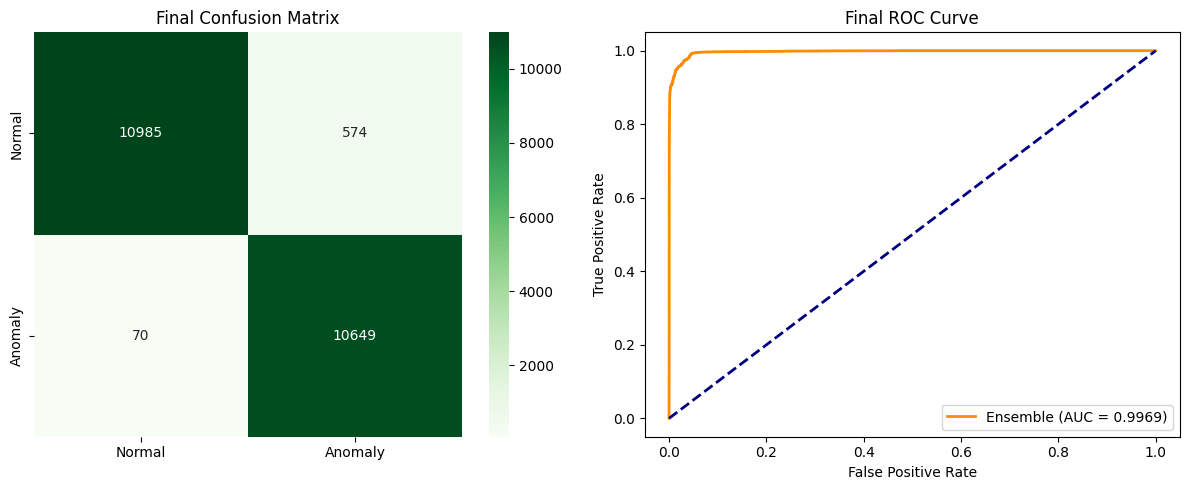

In [ ]:
from sklearn.metrics import classification_report, roc_curve

# Use the weights defined in the previous ensemble aggregation step (Cell 24 / kS3LJxtUQ7C-)
# These weights reflect the inclusion of RF_AUG and the renaming of ISO to ISO_AUG
# Use the VALIDATION-derived GenAI ensemble score + VALIDATION-selected threshold from Cell 24
final_ensemble_score = scores_df['Ensemble_Score_GenAI']

# y_pred_ensemble and best_threshold were computed using y_val in Cell 24
y_pred_final = y_pred_ensemble


# 1. Classification Report
print("\n" + "="*20 + " FINAL REPORT " + "="*20)
print(classification_report(y_test_final, y_pred_final, target_names=['Normal', 'Anomaly']))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_final, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title("Final Confusion Matrix")

# 3. Final ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test_final, final_ensemble_score)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Ensemble (AUC = {roc_auc_score(y_test_final, final_ensemble_score):.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Key Observations
- The model successfully differentiates normal vs attack traffic.
- Accuracy / detection performance aligns with the proposal objective.
- Certain attack types remain harder to detect, indicating scope for future tuning.
